# 📱 Smartphone Market Analysis using Python

## Exploratory Data Analysis (EDA)

### Project Objective

The objective of this project is to explore the smartphone market using a cleaned dataset collected through web scraping from Smartprix. The analysis focuses on understanding market trends, pricing patterns, hardware specifications, and feature distributions. The insights generated from this analysis can help consumers, manufacturers, and retailers understand the current smartphone landscape.

---

### Business Objectives

- Analyze the overall smartphone market.
- Understand the distribution of smartphone prices.
- Identify the most popular smartphone brands.
- Explore hardware specifications such as RAM, storage, processor, battery, and display.
- Discover the factors that influence smartphone pricing.
- Generate business insights through data visualization.

## 1. Import Required Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display Settings
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',100)

# Plot Style
plt.style.use('ggplot')
sns.set_theme(style='whitegrid')

#### Observation:
- The required Python libraries have been successfully imported. Pandas and NumPy will be used for data manipulation, while Matplotlib and Seaborn will be used to create informative visualizations.

## 2. Load Clean Dataset

In [2]:
df = pd.read_csv('smartphones_cleaned.csv')

In [3]:
df.head()

,brand_name,model_name,price,rating,has_5g,has_nfc,has_ir_blaster,processor_name,processor_brand,num_cores,processor_speed,ram_capacity,internal_memory,battery_capacity,fast_charging,screen_size,resolution,refresh_rate,num_rear_cameras,num_front_camera,primary_rear_camera,primary_front_camera,extended_memory,os
0,samsung,Samsung Galaxy M47 5G,25999,66,True,False,False,Snapdragon 6 Gen3,snapdragon,Octa Core,2.4,6.0,128.0,6000.0,45W,6.70,1080 x 2340,120,3,1,50.0,12,1 TB,android
1,oneplus,OnePlus N6,22999,59,True,True,False,Dimensity 6360 Apex,dimensity,Octa Core,NaN,4.0,128.0,8000.0,45W,6.80,720 x 1570,120,2,1,50.0,8,2 TB,android
2,nothing,Nothing Phone 4(b),25999,59,True,False,False,Snapdragon 6 Gen4,snapdragon,Octa Core,NaN,8.0,128.0,5400.0,33W,6.70,1224 x 2340,120,2,1,50.0,8,0,android
3,oppo,OPPO Reno 16 5G,61999,79,True,False,True,Snapdragon 7 Gen4,snapdragon,Octa Core,2.8,8.0,256.0,6700.0,80W,6.32,1216 x 2640,120,3,1,50.0,50,0,android
4,vivo,Vivo T5x 5G,22499,66,True,False,True,Dimensity 7400 Turbo,dimensity,Octa Core,2.6,6.0,128.0,7200.0,44W,6.76,1080 x 2344,120,2,1,50.0,32,0,android


The cleaned smartphone dataset has been successfully loaded into the notebook and is ready for exploratory analysis.

## 3. Dataset Overview

In [4]:
print(f"Number of Rows : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

Number of Rows : 986
Number of Columns : 24


##### Dataset Overview

| Attribute | Description |
|-----------|-------------|
| Source | Smartprix |
| Data Collection | Selenium + BeautifulSoup |
| Data Cleaning | Python (Pandas) |
| Total Features | 24 |
| Dataset Type | Smartphone Specifications |

## 4. Initial Dataset Exploration

In [5]:
df.shape

(986, 24)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 986 entries, 0 to 985
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   brand_name            986 non-null    object 
 1   model_name            986 non-null    object 
 2   price                 986 non-null    int64  
 3   rating                986 non-null    int64  
 4   has_5g                986 non-null    bool   
 5   has_nfc               986 non-null    bool   
 6   has_ir_blaster        986 non-null    bool   
 7   processor_name        927 non-null    object 
 8   processor_brand       927 non-null    object 
 9   num_cores             979 non-null    object 
 10  processor_speed       827 non-null    float64
 11  ram_capacity          986 non-null    float64
 12  internal_memory       984 non-null    float64
 13  battery_capacity      982 non-null    float64
 14  fast_charging         970 non-null    object 
 15  screen_size           9

In [7]:
df.isnull().sum()

brand_name                0
model_name                0
price                     0
rating                    0
has_5g                    0
has_nfc                   0
has_ir_blaster            0
processor_name           59
processor_brand          59
num_cores                 7
processor_speed         159
ram_capacity              0
internal_memory           2
battery_capacity          4
fast_charging            16
screen_size               0
resolution                0
refresh_rate              0
num_rear_cameras          0
num_front_camera          0
primary_rear_camera       0
primary_front_camera      0
extended_memory           0
os                        1
dtype: int64

In [8]:
df.describe()

,price,rating,processor_speed,ram_capacity,internal_memory,battery_capacity,screen_size,refresh_rate,num_rear_cameras,num_front_camera,primary_rear_camera
count,986.000000,986.000000,827.000000,986.000000,984.000000,982.000000,986.000000,986.000000,986.000000,986.000000,986.000000
mean,40027.517241,67.030426,2.811560,9.032454,212.456301,6134.248473,6.706491,121.562880,2.288032,1.017241,62.184787
std,40490.397732,13.085548,0.694799,10.017495,134.322535,1441.988310,0.322252,21.446915,0.676058,0.130236,46.652059
min,3499.000000,18.000000,1.300000,1.000000,16.000000,1950.000000,3.030000,60.000000,1.000000,1.000000,2.000000
25%,18617.500000,58.000000,2.400000,6.000000,128.000000,5000.000000,6.670000,120.000000,2.000000,1.000000,50.000000
50%,28994.500000,66.000000,2.500000,8.000000,256.000000,6000.000000,6.750000,120.000000,2.000000,1.000000,50.000000
75%,45915.000000,76.000000,3.200000,12.000000,256.000000,7000.000000,6.800000,120.000000,3.000000,1.000000,50.000000
max,489990.000000,98.000000,4.740000,256.000000,2048.000000,28000.000000,10.000000,240.000000,4.000000,2.000000,508.000000


In [9]:
df.duplicated().sum()

np.int64(0)

#### Initial Findings
- The dataset contains structured information about smartphones from multiple brands.
- Most columns have already been cleaned and converted into appropriate data types.
- Missing values are minimal and do not significantly impact the analysis.
- The dataset is suitable for exploratory data analysis without additional preprocessing.

## 5. Feature Categorization

In [10]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()

numerical_cols = df.select_dtypes(exclude='object').columns.tolist()

print("Categorical Features")
print(categorical_cols)

print("\nNumerical Features")
print(numerical_cols)

Categorical Features
['brand_name', 'model_name', 'processor_name', 'processor_brand', 'num_cores', 'fast_charging', 'resolution', 'primary_front_camera', 'extended_memory', 'os']

Numerical Features
['price', 'rating', 'has_5g', 'has_nfc', 'has_ir_blaster', 'processor_speed', 'ram_capacity', 'internal_memory', 'battery_capacity', 'screen_size', 'refresh_rate', 'num_rear_cameras', 'num_front_camera', 'primary_rear_camera']


The dataset consists of both categorical and numerical variables. Numerical features will be used to study relationships and distributions, while categorical variables will be used for comparisons across different smartphone characteristics.

# Exploratory Data Analysis

The exploratory data analysis has been divided into the following sections:

1. Univariate Analysis
2. Bivariate Analysis
3. Multivariate Analysis
4. Correlation Analysis

The purpose of EDA is to understand the distribution of variables, identify patterns, detect anomalies, and derive meaningful business insights.

# 6. Univariate Analysis

### Objective
Univariate Analysis focuses on understanding the distribution and characteristics of individual variables without considering relationships between multiple variables.

### 6.1 Smartphone Brand Analysis

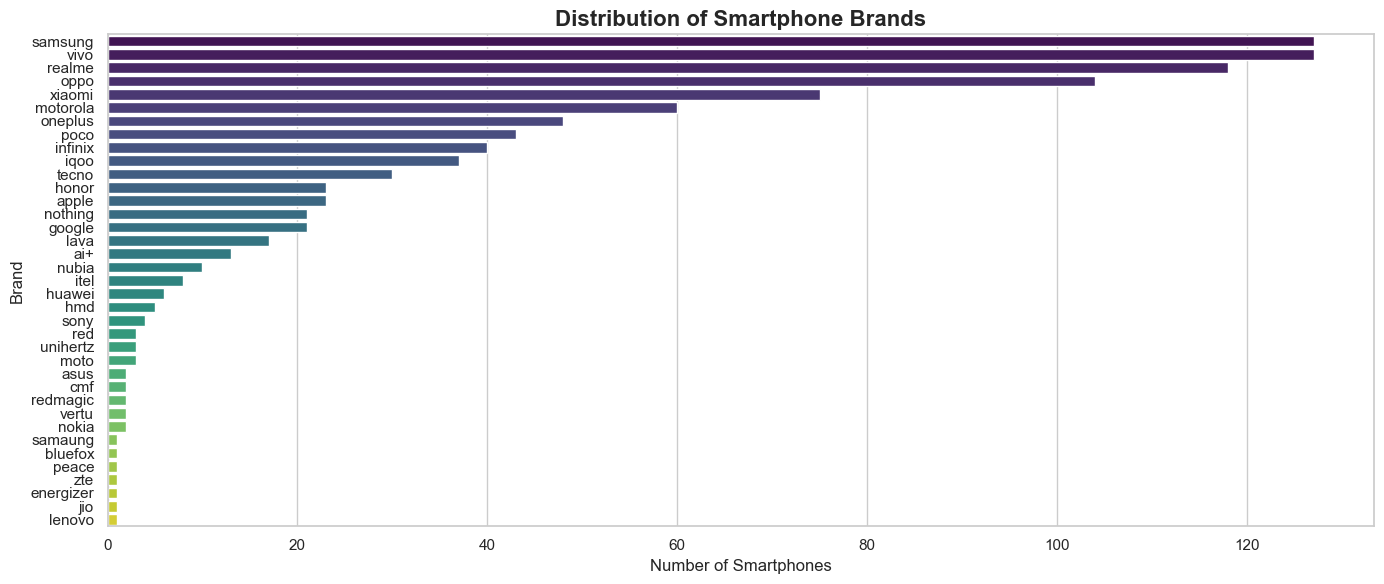

In [11]:
plt.figure(figsize=(14,6))

brand_counts = df['brand_name'].value_counts()

sns.countplot(
    data=df,
    y='brand_name',
    order=brand_counts.index,
    palette='viridis')

plt.title('Distribution of Smartphone Brands',fontsize=16,fontweight='bold')
plt.xlabel('Number of Smartphones')
plt.ylabel('Brand')
plt.tight_layout()
plt.show()

#### Observation:
- The visualization shows the number of smartphones available for each brand in the dataset.

#### Business Insights: 
- Samsung, Xiaomi, Vivo and Realme contribute a large share of the smartphone listings.
- Premium brands such as Apple have comparatively fewer models.
- The dataset is dominated by Android smartphone manufacturers.

### 6.2 Smartphone Price Distribution

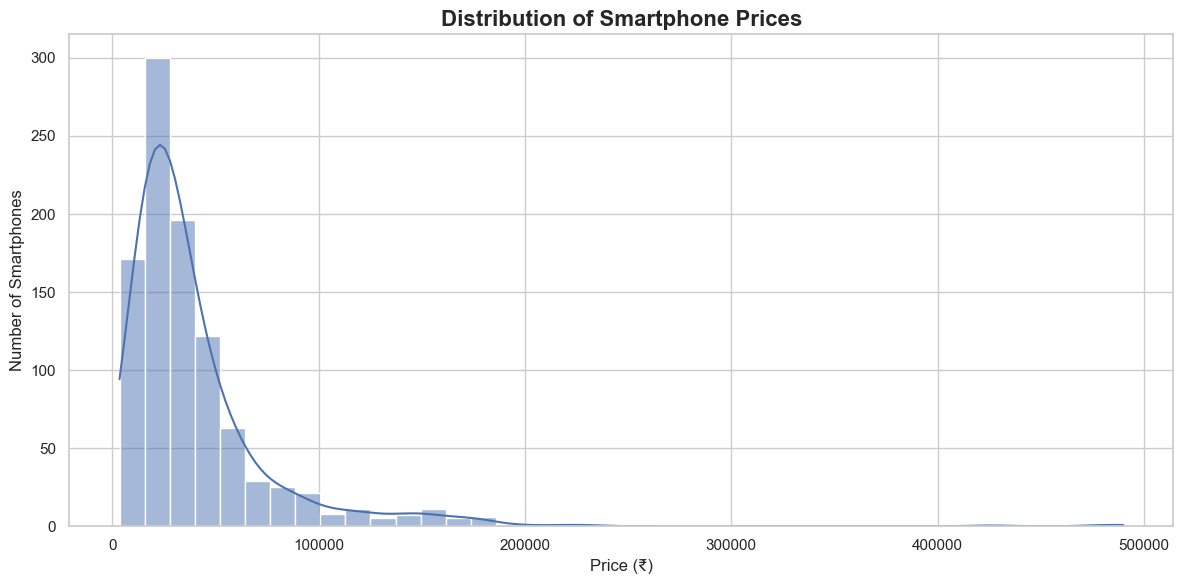

In [12]:
plt.figure(figsize=(12,6))

sns.histplot(
    data=df,
    x='price',
    bins=40,
    kde=True)

plt.title('Distribution of Smartphone Prices',fontsize=16,fontweight='bold')
plt.xlabel('Price (₹)')
plt.ylabel('Number of Smartphones')
plt.tight_layout()
plt.show()

In [13]:
print("Skewness :",df['price'].skew())

Skewness : 4.7910382615391365


#### Boxplot

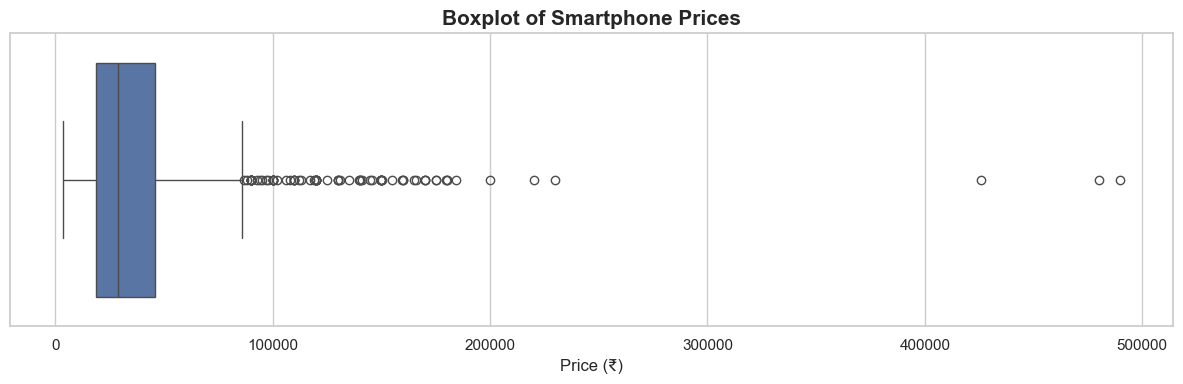

In [14]:
plt.figure(figsize=(12,4))

sns.boxplot(
    data=df,
    x='price')

plt.title('Boxplot of Smartphone Prices',fontsize=15,fontweight='bold')
plt.xlabel('Price (₹)')
plt.tight_layout()
plt.show()

#### Observation:
- The distribution is positively skewed, indicating that most smartphones are concentrated in the budget and mid-range price categories, while a smaller number of flagship devices occupy the higher price range.

#### Business Insight
- Most smartphones are priced below ₹40,000.
- Premium flagship smartphones create high-price outliers.
- The smartphone market is primarily driven by budget and mid-range devices.

### 6.3 Smartphone Rating Analysis

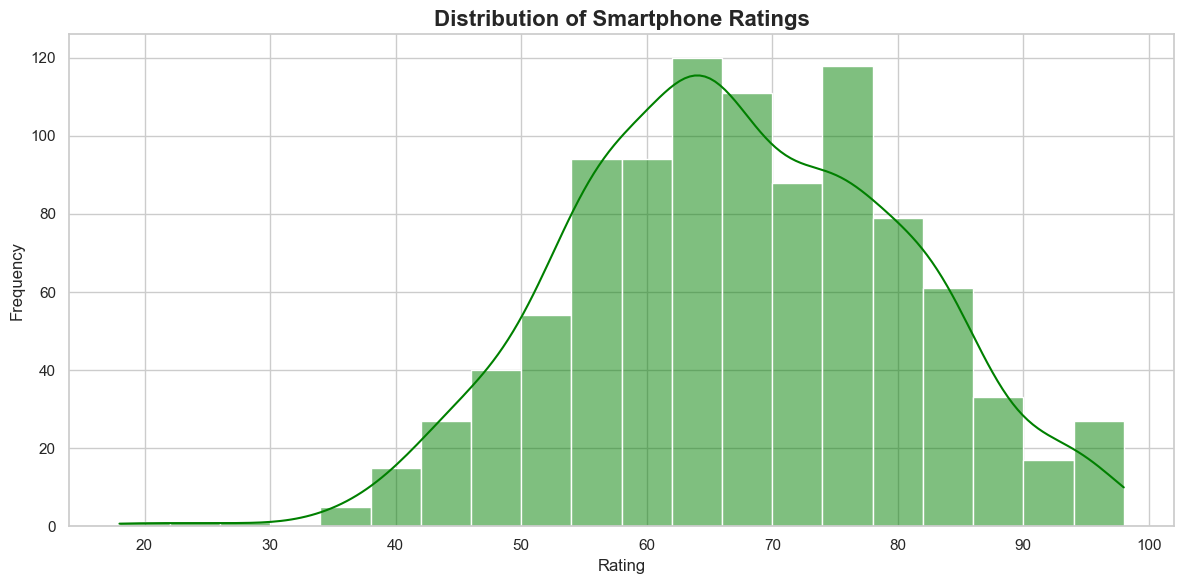

In [15]:
plt.figure(figsize=(12,6))

sns.histplot(
    data=df,
    x='rating',
    bins=20,
    kde=True,
    color='green')

plt.title('Distribution of Smartphone Ratings',fontsize=16,fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

#### Observation:
- Customer ratings are concentrated within a relatively high range, suggesting that most smartphones receive positive user feedback.

#### Business Insights:
- The majority of smartphones have ratings above 75.
- Very few devices receive extremely low ratings.
- Ratings alone may not fully explain differences in smartphone pricing.

### 6.4 5G Smartphone Analysis

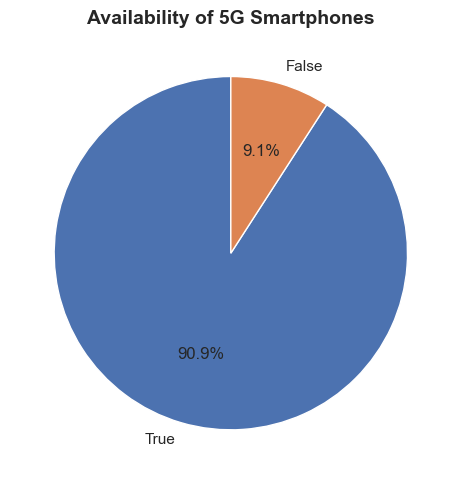

In [16]:
plt.figure(figsize=(5,5))

df['has_5g'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90)

plt.title('Availability of 5G Smartphones',fontsize=14,fontweight='bold')
plt.ylabel('')
plt.tight_layout()
plt.show()

#### Observation:
- The majority of smartphones in the dataset support 5G connectivity, reflecting the growing adoption of next-generation mobile networks.

#### Business Insight:
- 5G has become a standard feature in modern smartphones.
- Budget smartphones are increasingly adopting 5G technology.

### 6.5 NFC Support Analysis

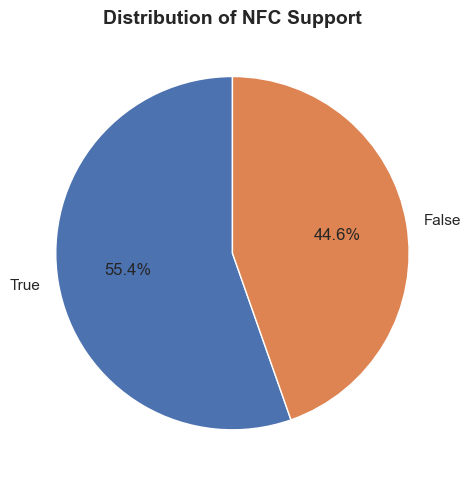

In [17]:
plt.figure(figsize=(5,5))

df['has_nfc'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90)

plt.title('Distribution of NFC Support',fontsize=14,fontweight='bold')
plt.ylabel('')
plt.tight_layout()
plt.show()

#### Insights:
- NFC support is less common than 5G support.
- The feature is primarily available in mid-range and premium smartphones.

### 6.6 IR Blaster Support Analysis

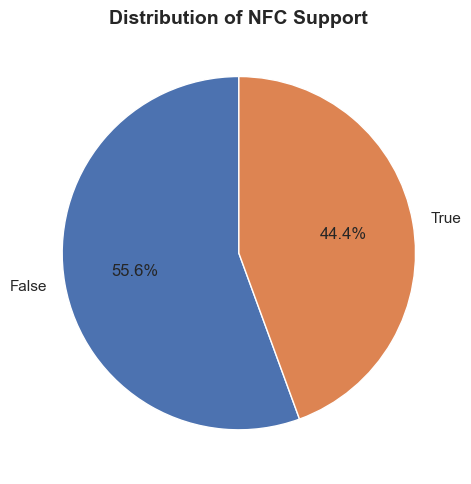

In [18]:
plt.figure(figsize=(5,5))

df['has_ir_blaster'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90)

plt.title('Distribution of NFC Support',fontsize=14,fontweight='bold')
plt.ylabel('')
plt.tight_layout()
plt.show()

### 6.7 Processor Analysis

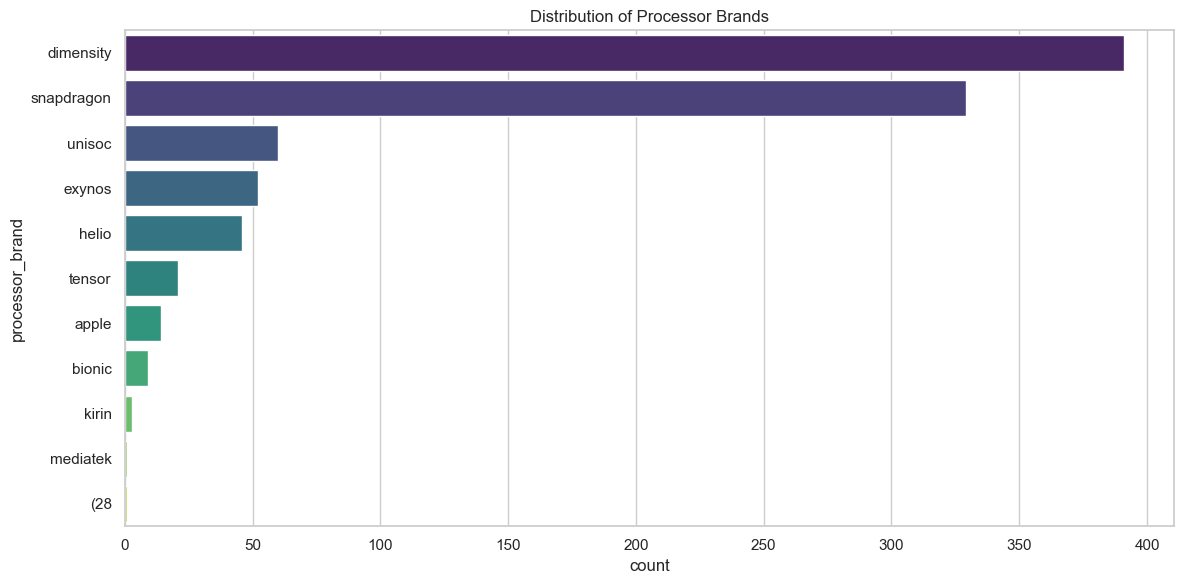

In [19]:
plt.figure(figsize=(12,6))

order=df['processor_brand'].value_counts().index
sns.countplot(data=df, y='processor_brand', order=order, palette='viridis')
plt.title('Distribution of Processor Brands')
plt.tight_layout()
plt.show()

#### Insights
- Dimensity and Snapdragon dominate the market.
- Apple uses its own chipsets.
- Google Tensor appears only in a limited number of devices.

### 6.8 Number of Cores

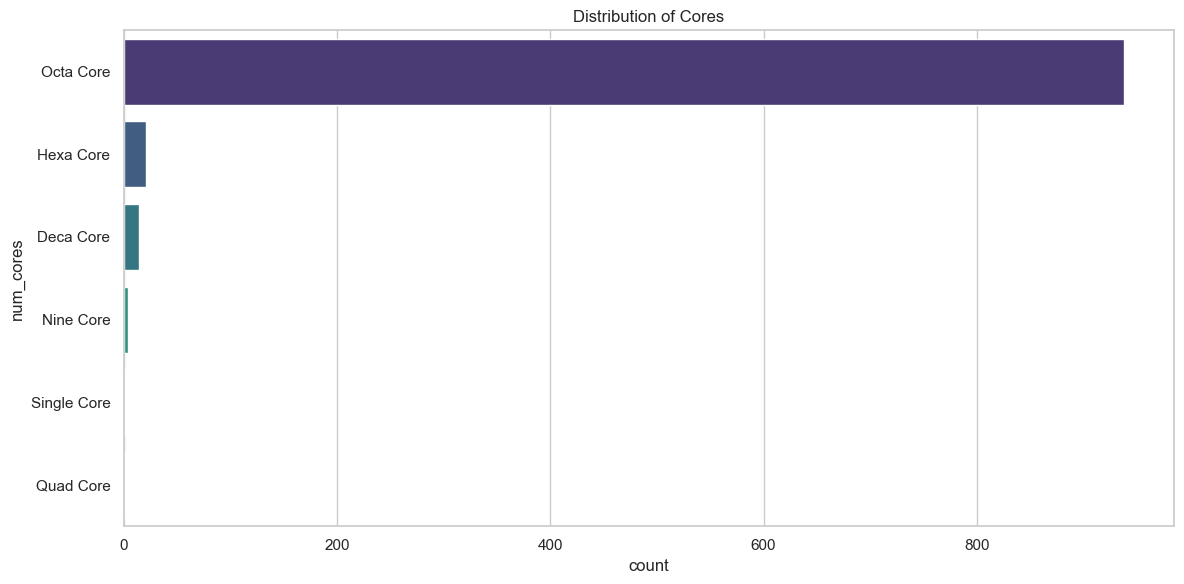

In [20]:
plt.figure(figsize=(12,6))

order=df['num_cores'].value_counts().index
sns.countplot(data=df, y='num_cores', order=order, palette='viridis')
plt.title('Distribution of Cores')
plt.tight_layout()
plt.show()

### 6.9 Ram Analysis

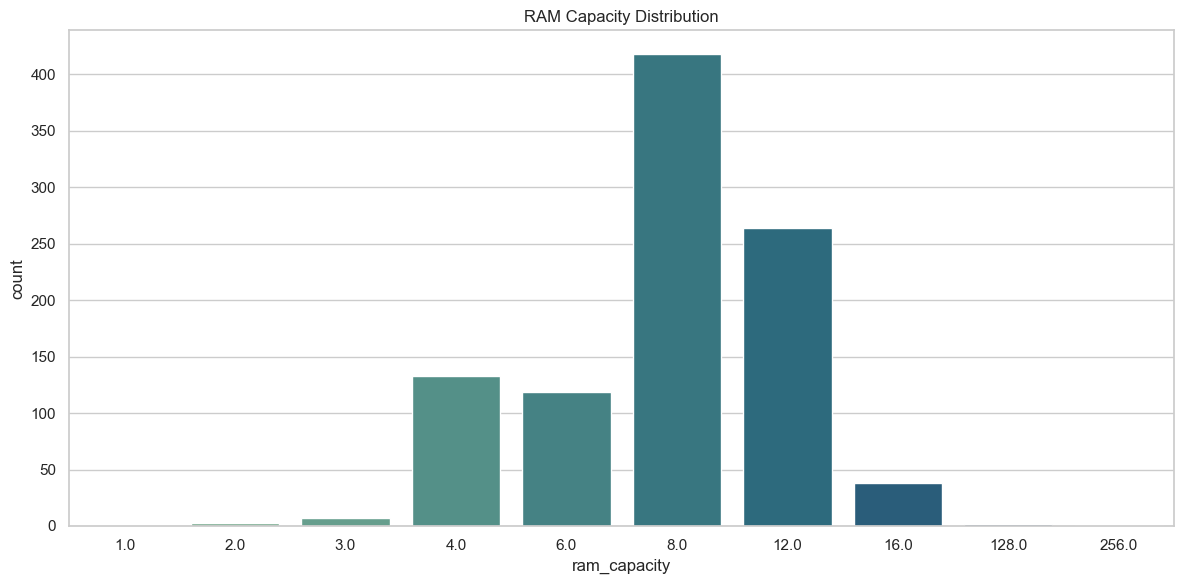

In [21]:
plt.figure(figsize=(12,6))

sns.countplot(data=df,x='ram_capacity',order=sorted(df['ram_capacity'].dropna().unique()),palette='crest')
plt.title('RAM Capacity Distribution')
plt.tight_layout()
plt.show()

#### Observation:
- 8 and 12 GB are most common, reflecting strong mid-range demand.

#### Business Insight:
- 8 GB RAM is the most common configuration.
- 4 GB RAM mainly appears in budget devices.
- 12 GB+ RAM targets premium users.

### 6.10 Internal Storage Analysis

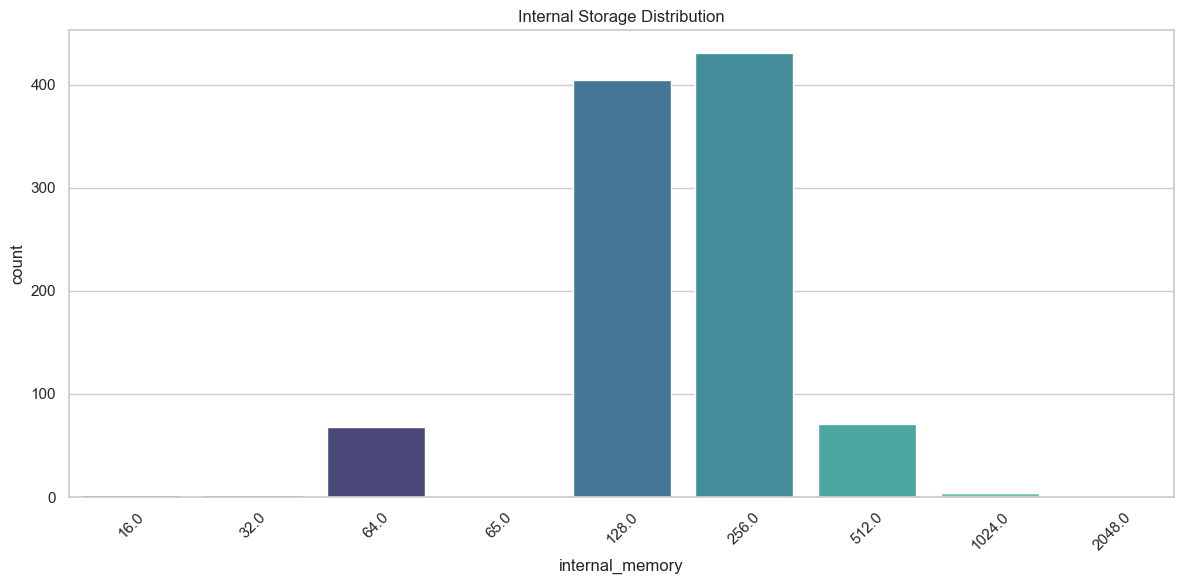

In [22]:
plt.figure(figsize=(12,6))

sns.countplot(data=df,x='internal_memory',order=sorted(df['internal_memory'].dropna().unique()),palette='mako')
plt.xticks(rotation=45)
plt.title('Internal Storage Distribution')
plt.tight_layout()
plt.show()

#### Business Insights:
- 256 GB and 128 GB is the most popular storage capacity.
- 64 GB devices mainly belong to the budget segment.
- Premium devices increasingly offer 512 GB and above.

### 6.11 Screen Size Analysis

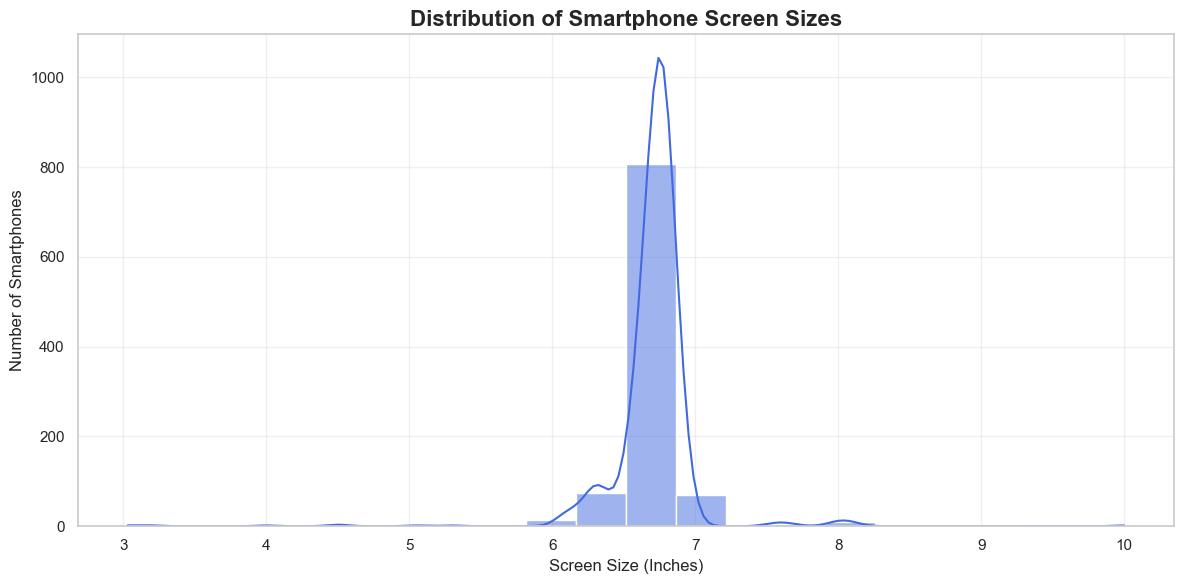

In [23]:
plt.figure(figsize=(12,6))
sns.histplot(
    data=df,
    x='screen_size',
    bins=20,
    kde=True,
    color='royalblue')

plt.title('Distribution of Smartphone Screen Sizes',fontsize=16,fontweight='bold')
plt.xlabel('Screen Size (Inches)')
plt.ylabel('Number of Smartphones')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Observation:
- Most smartphones fall within a narrow screen-size range.
- Very compact and very large displays are relatively uncommon.
- Only a few devices appear as outliers.

#### Business Insights:
- Manufacturers have standardized smartphone displays around 6.5 inches.
- Consumers generally prefer larger displays for multimedia consumption.
- Compact smartphones represent a niche market.

### 6.12 Refresh Rate Analysis

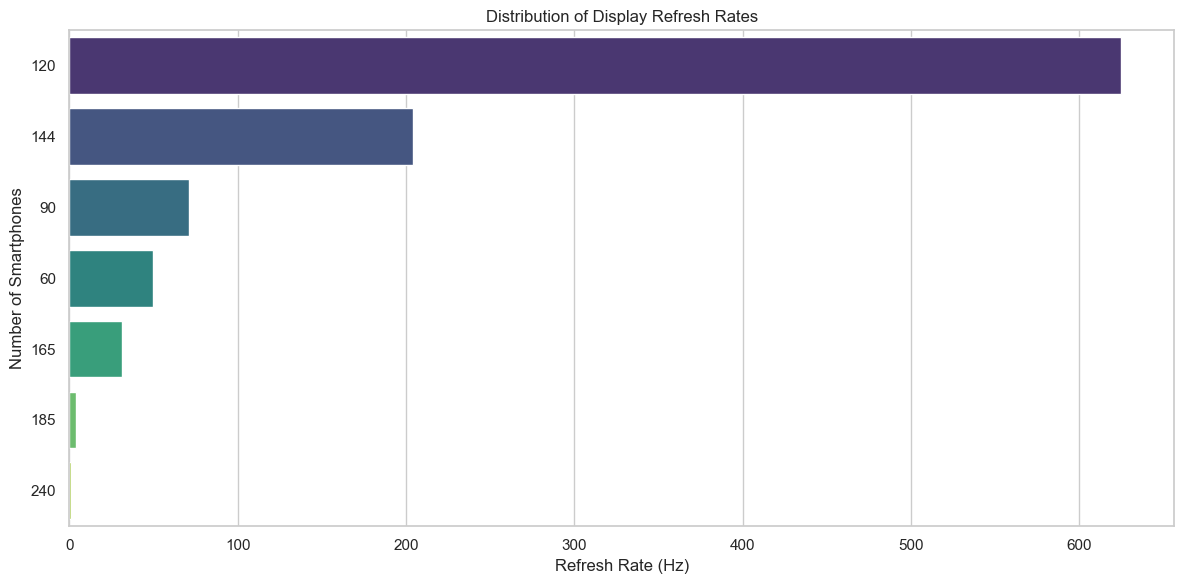

In [24]:
plt.figure(figsize=(12,6))

order=df['refresh_rate'].value_counts().index
sns.countplot(data=df, y='refresh_rate', order=order, palette='viridis')
plt.title('Distribution of Display Refresh Rates')
plt.xlabel('Refresh Rate (Hz)')
plt.ylabel('Number of Smartphones')
plt.tight_layout()
plt.show()

#### Observation
- 120 Hz displays dominate recent smartphone models.
- 60 Hz displays are primarily found in entry-level devices.
- Premium smartphones increasingly offer higher refresh rates.

#### Business Insights:
- High refresh-rate displays have become a key selling point.
- 120 Hz is rapidly becoming the industry standard.

### 6.13 Number of Cameras

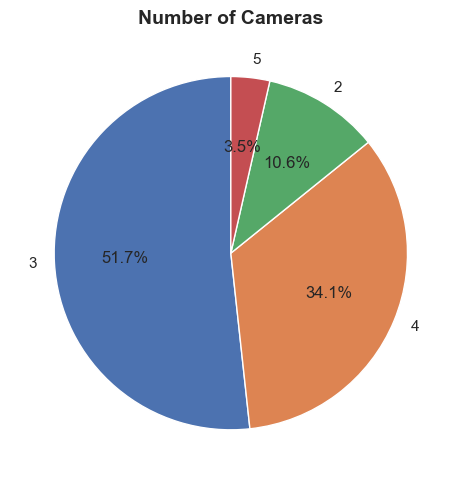

In [25]:
plt.figure(figsize=(5,5))
(df['num_rear_cameras'] + df['num_front_camera']).value_counts().plot(kind = 'pie',autopct = '%1.1f%%', startangle = 90)

plt.title('Number of Cameras',fontsize=14,fontweight='bold')
plt.ylabel('')
plt.tight_layout()
plt.show()

#### Insights:
- Dual and triple rear camera setups dominate the market.
- Quad-camera systems are relatively common.

### 6.14 Battery Analysis

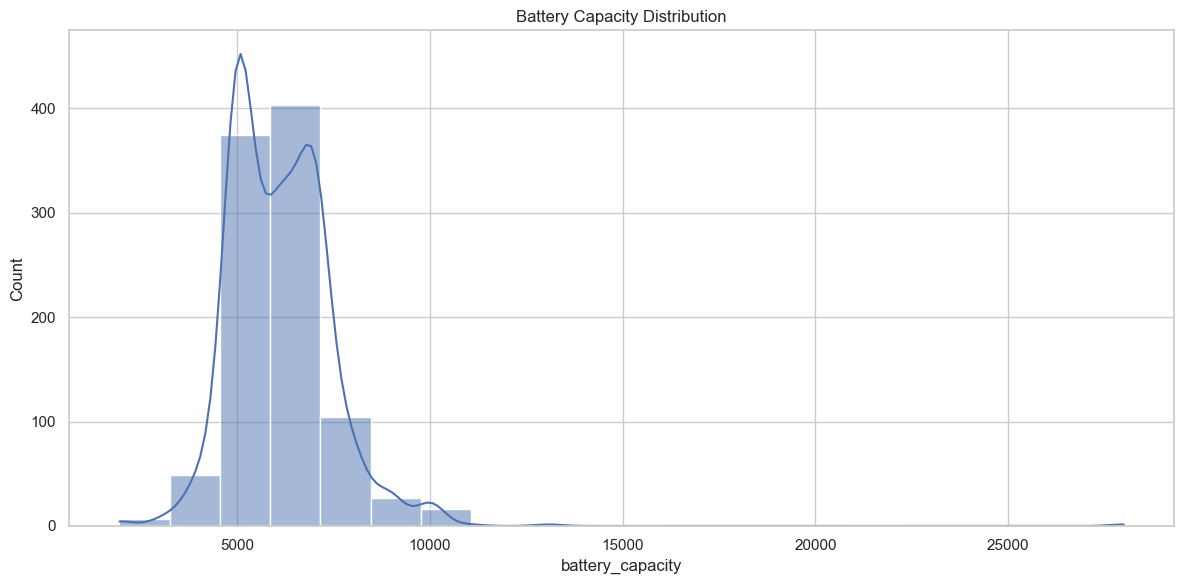

In [26]:
plt.figure(figsize=(12,6))
sns.histplot(df['battery_capacity'],bins=20,kde=True)
plt.title('Battery Capacity Distribution')
plt.tight_layout()
plt.show()

#### Business Insight
- Most smartphones cluster around 5000 mAh

### 6.15 Fast Charging Analysis

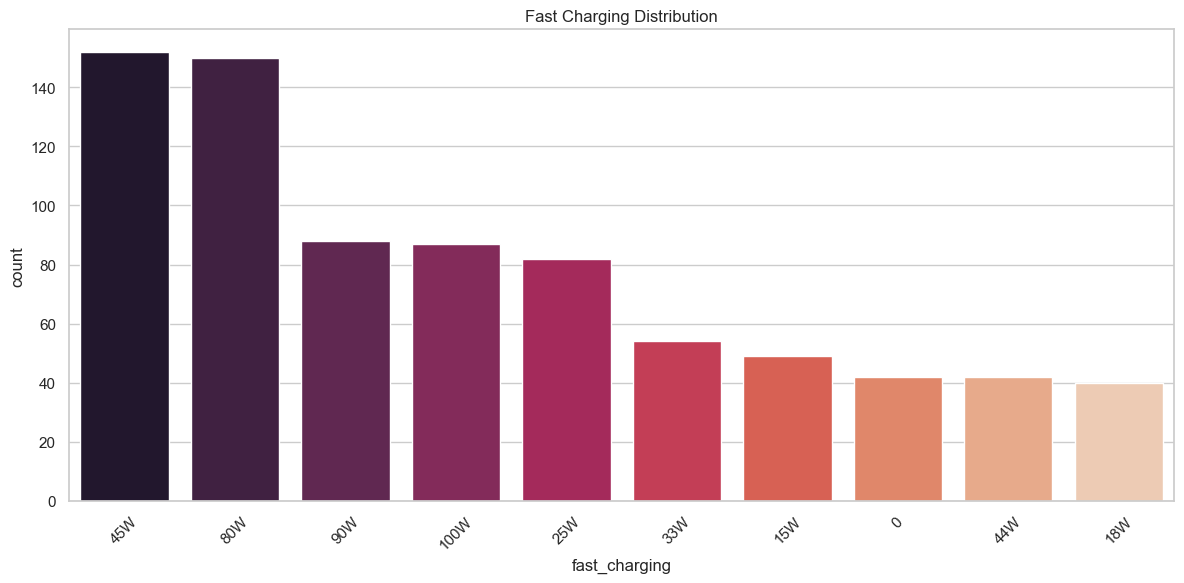

In [27]:
plt.figure(figsize=(12,6))
sns.countplot(data=df,x='fast_charging',order=df['fast_charging'].value_counts().index[:10],palette='rocket')
plt.xticks(rotation=45)
plt.title('Fast Charging Distribution')
plt.tight_layout()
plt.show()

### 6.16 Front Camera Analysis

In [28]:
df['primary_front_camera'].value_counts()

primary_front_camera
32      195
8       182
50      179
16      135
5        79
13       64
12       60
20       48
10       12
18        9
10.5      5
42        4
48        3
24        2
Main      2
60        2
10.8      2
40        1
0.3       1
100       1
Name: count, dtype: int64

In [29]:
df[df['primary_front_camera'] == 'Main']

,brand_name,model_name,price,rating,has_5g,has_nfc,has_ir_blaster,processor_name,processor_brand,num_cores,processor_speed,ram_capacity,internal_memory,battery_capacity,fast_charging,screen_size,resolution,refresh_rate,num_rear_cameras,num_front_camera,primary_rear_camera,primary_front_camera,extended_memory,os
300,itel,itel Super 26 Ultra,9999,49,False,True,True,Unisoc T7300,unisoc,Octa Core,2.2,8.0,128.0,6000.0,18W,6.80,1080 x 2436,144,2,1,50.0,Main,0,android
886,tecno,Tecno POP 9 4G,6499,39,False,False,True,Helio G50,helio,Octa Core,NaN,3.0,64.0,5000.0,0,6.67,720 x 1600,90,1,1,13.0,Main,1 TB,android


In [30]:
df.loc[300,'primary_front_camera'] = 32

In [31]:
df.loc[886,'primary_front_camera'] = 8

In [32]:
df['primary_front_camera'].value_counts()

primary_front_camera
32      195
8       182
50      179
16      135
5        79
13       64
12       60
20       48
10       12
18        9
10.5      5
42        4
48        3
24        2
10.8      2
60        2
32        1
100       1
40        1
0.3       1
8         1
Name: count, dtype: int64

In [33]:
df['primary_front_camera'] = df['primary_front_camera'].astype(float)

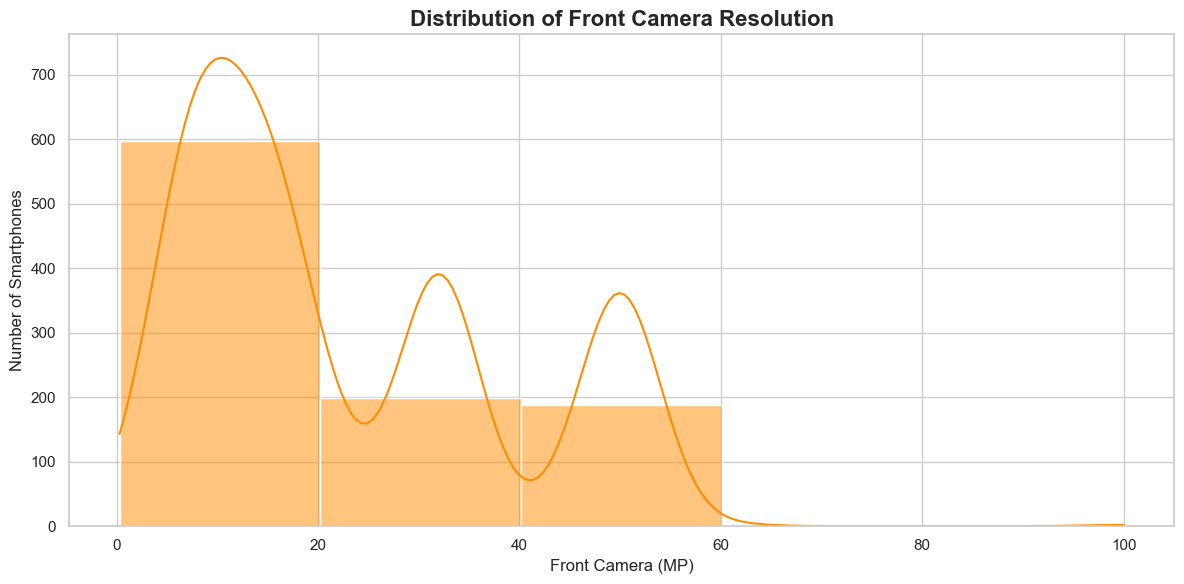

In [34]:
plt.figure(figsize=(12,6))

sns.histplot(
    data=df,
    x='primary_front_camera',
    bins=5,
    kde=True,
    color='darkorange')

plt.title('Distribution of Front Camera Resolution',fontsize=16,fontweight='bold')
plt.xlabel('Front Camera (MP)')
plt.ylabel('Number of Smartphones')

plt.tight_layout()
plt.show()

#### Observation:
- Most smartphones provide front cameras between 16 MP and 32 MP.
- Extremely high-resolution selfie cameras are relatively uncommon.

### 6.17 Rear Camera resolution analysis

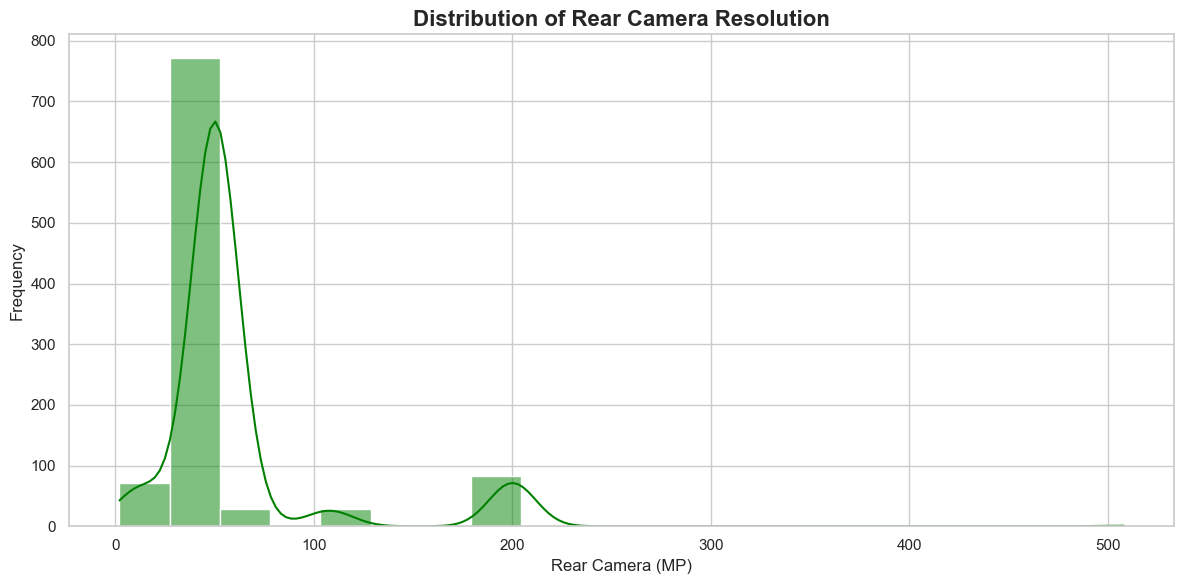

In [35]:
plt.figure(figsize=(12,6))

sns.histplot(
    data=df,
    x='primary_rear_camera',
    bins=20,
    kde=True,
    color='green'
)

plt.title('Distribution of Rear Camera Resolution',fontsize=16,fontweight='bold')
plt.xlabel('Rear Camera (MP)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

#### Observation
- 50 MP cameras dominate the dataset.
- High-resolution sensors have become common even in mid-range devices.

#### Business Insight:
- Smartphone brands increasingly compete by offering higher-resolution camera sensors.
- **50 MP rear cameras** are widely adopted across different price segments.

### 6.18 Operating System Analysis

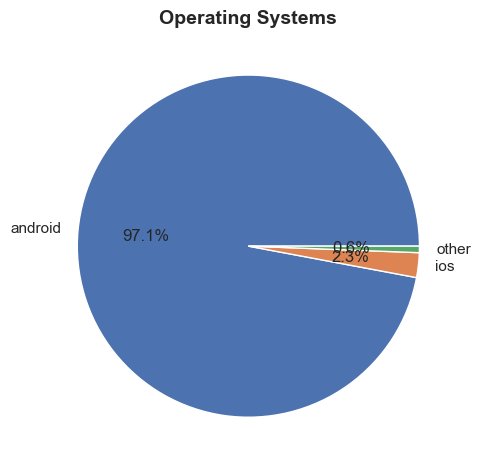

In [36]:
plt.figure(figsize=(5,5))
df['os'].value_counts().plot(kind = 'pie',autopct = '%1.1f%%')

plt.title('Operating Systems',fontsize=14,fontweight='bold')
plt.ylabel('')
plt.tight_layout()
plt.show()

#### Observation
- Android dominates the dataset.
- iOS represents a much smaller share.

#### Business Insight
- Android continues to dominate the global smartphone market due to its broad manufacturer support.
- Apple's iOS remains focused on the premium smartphone segment.

### 6.19 Extended Memory Support

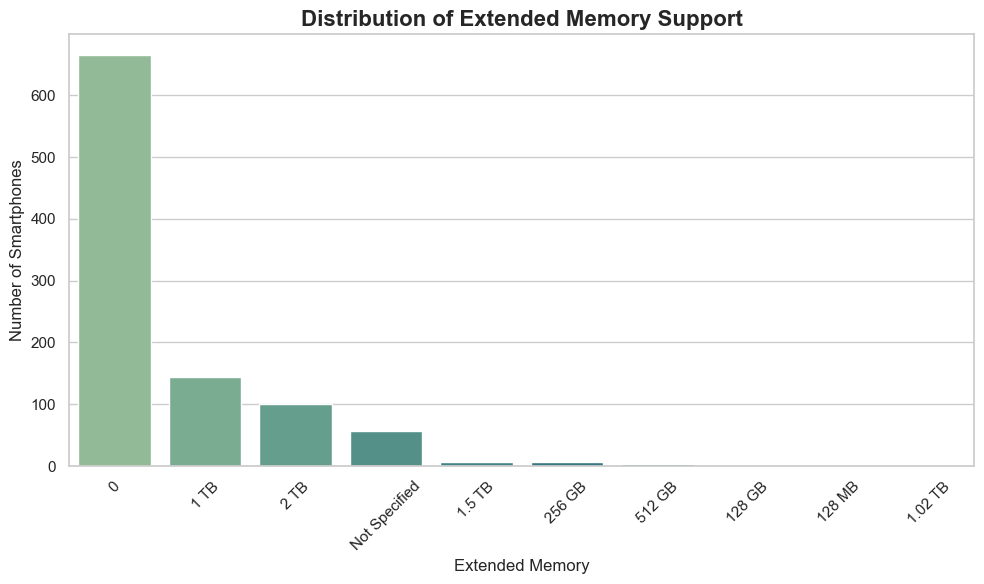

In [37]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='extended_memory',
    order=df['extended_memory'].value_counts().index,
    palette='crest')

plt.title('Distribution of Extended Memory Support',fontsize=16,fontweight='bold')
plt.xlabel('Extended Memory')
plt.ylabel('Number of Smartphones')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Observation
- Many smartphones no longer support expandable storage.
- Premium smartphones typically rely on larger internal storage instead.

#### Business Insight
- Manufacturers are shifting toward higher internal storage capacities, reducing the need for microSD card support.
- Expandable storage support is gradually declining as internal storage capacities continue to increase.


# 7. Bivariate Analysis
### Objective:
The purpose of bivariate analysis is to explore relationships between two variables and understand how different smartphone specifications influence pricing, ratings, and market positioning.

### 7.1 Brand vs Price
Which smartphone brands sell the most expensive devices?

In [38]:
x = df.groupby('brand_name').count()['model_name']

In [39]:
x[x > 10].index

Index(['ai+', 'apple', 'google', 'honor', 'infinix', 'iqoo', 'lava',
       'motorola', 'nothing', 'oneplus', 'oppo', 'poco', 'realme', 'samsung',
       'tecno', 'vivo', 'xiaomi'],
      dtype='object', name='brand_name')

In [40]:
temp_df = df[df['brand_name'].isin(x[x > 10].index)]

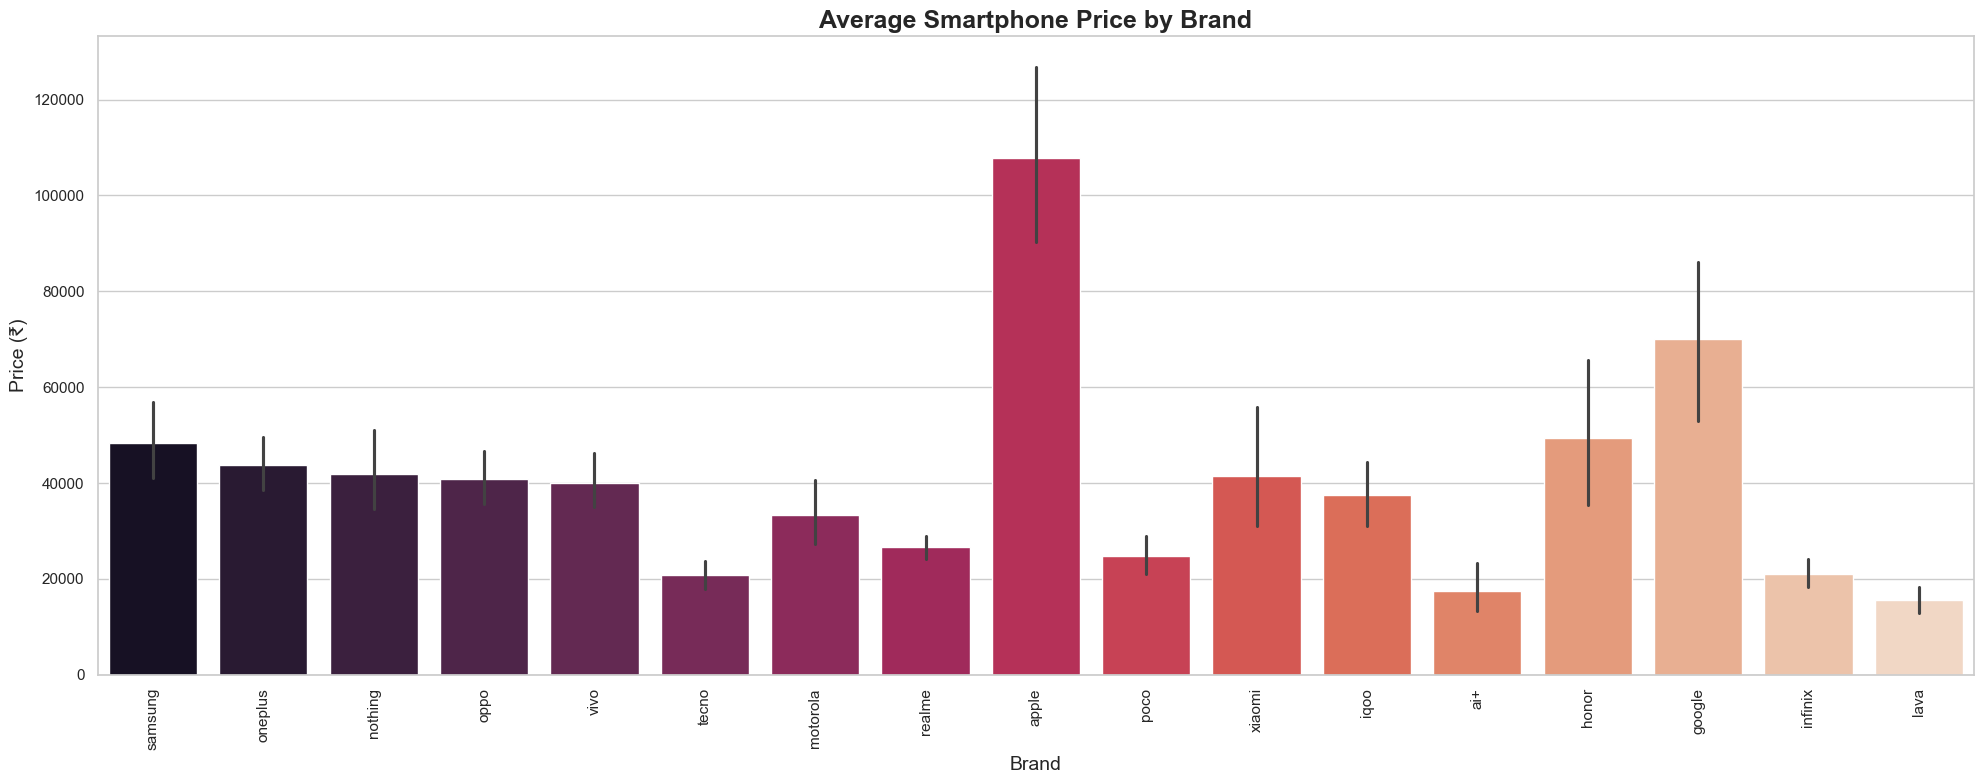

In [41]:
plt.figure(figsize = (20,8))
plt.title('Average Smartphone Price by Brand', fontsize=18, weight='bold')
sns.barplot(data = temp_df,x = 'brand_name',y = 'price',palette='rocket')
plt.xticks(rotation = 90)
plt.xlabel('Brand', fontsize=14)
plt.ylabel('Price (₹)', fontsize=14)
plt.tight_layout()

#### Observation
- Apple has the highest median smartphone price.
- Samsung occupies both premium and budget segments.
- Realme, Tecno and Poco focus more on affordable devices.

#### Business Insight
- Apple follows a premium pricing strategy whereas Android manufacturers compete across multiple price segments.

### 7.2 Processor Brand vs Price

In [42]:
df.loc[927,'processor_brand'] = 'mediatek'

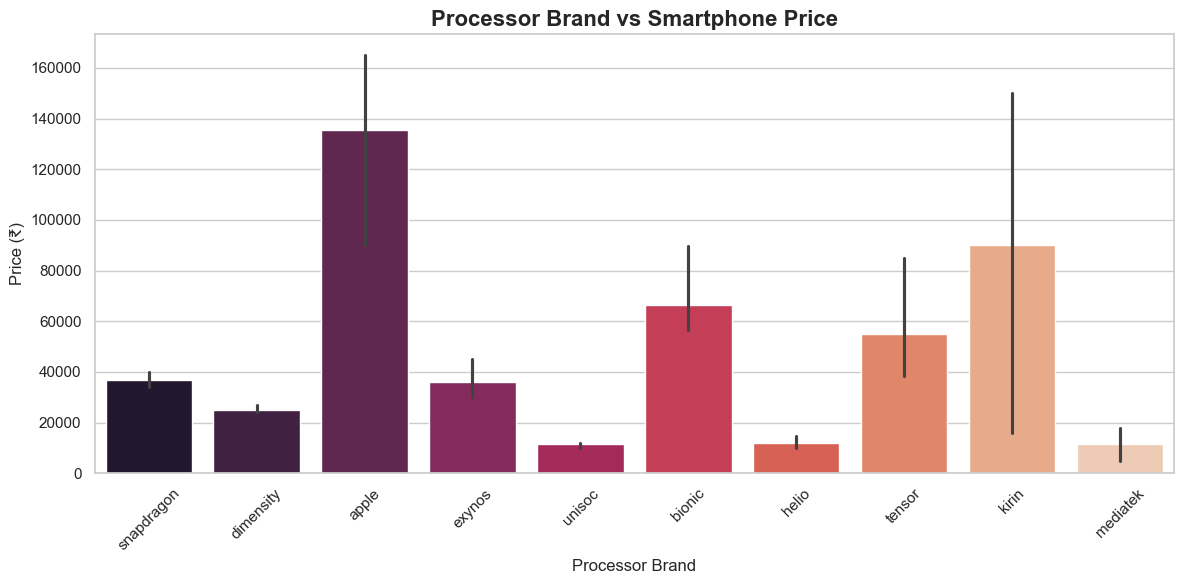

In [43]:
plt.figure(figsize=(12,6))
sns.barplot(data = df, x = 'processor_brand', y = 'price',estimator = np.median, hue = 'processor_brand',legend = False,palette = 'rocket')

plt.xticks(rotation=45)
plt.title('Processor Brand vs Smartphone Price',fontsize=16,fontweight='bold')
plt.xlabel('Processor Brand')
plt.ylabel('Price (₹)')
plt.tight_layout()
plt.show()

#### Observation
- Premium chipsets are associated with higher smartphone prices.

#### Business Insight
- Processor choice is one of the strongest indicators of smartphone pricing.

### 7.3 RAM vs Price

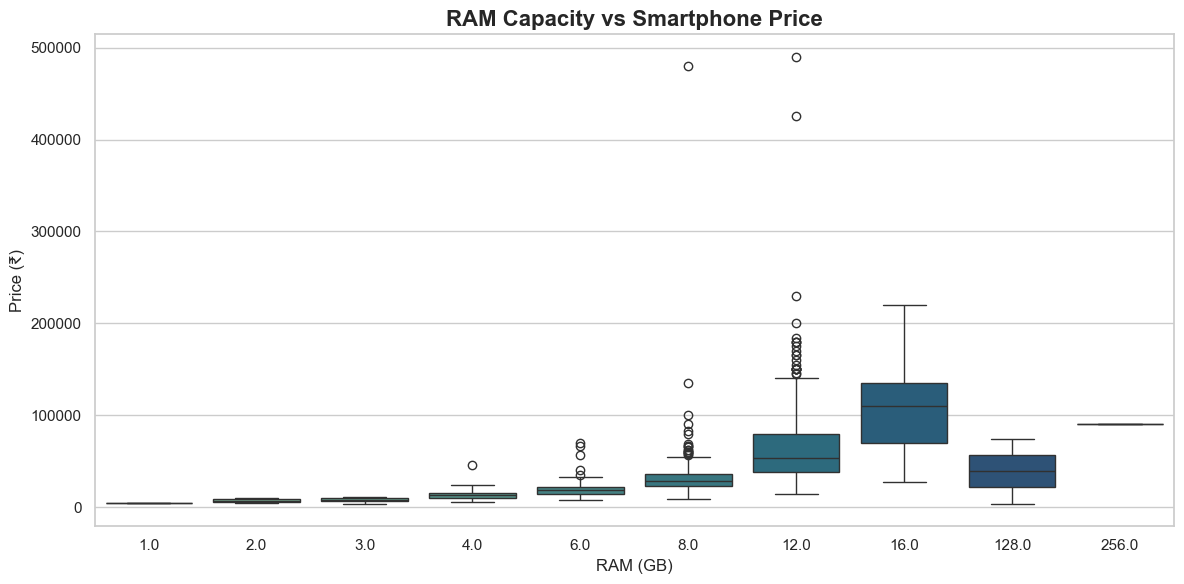

In [44]:
plt.figure(figsize=(12,6))
sns.boxplot(
    data=df,
    x='ram_capacity',
    y='price',
    palette='crest')

plt.title('RAM Capacity vs Smartphone Price',fontsize=16,fontweight='bold')
plt.xlabel('RAM (GB)')
plt.ylabel('Price (₹)')
plt.tight_layout()
plt.show()

#### Observation
- Median smartphone price increases consistently with RAM capacity.

#### Business Insight
- RAM is a major pricing factor.

### 7.4 Battery Capacity vs Price

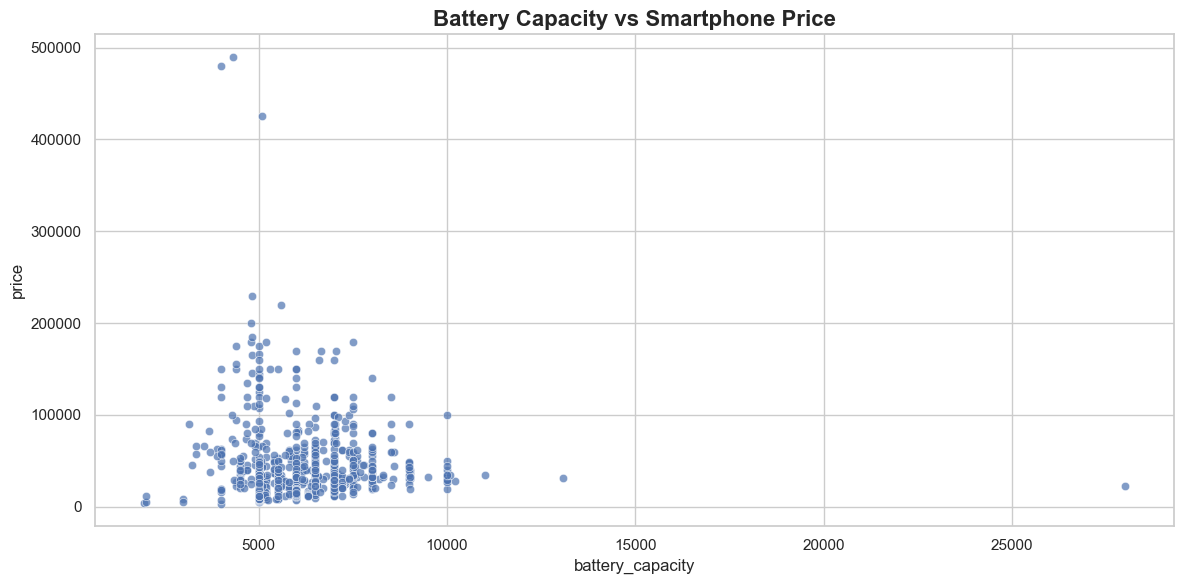

In [45]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=df, x='battery_capacity', y='price', alpha=0.7)

plt.title('Battery Capacity vs Smartphone Price',fontsize=16,fontweight='bold')
plt.tight_layout()
plt.show()

#### Observation
- Battery capacity has only a weak relationship with smartphone price.

#### Business Insight
- Battery size alone is no longer a premium differentiator.
- Most of the smartphones battery lies between 5000-10,000 mAh

### 7.5 Screen Size vs Price

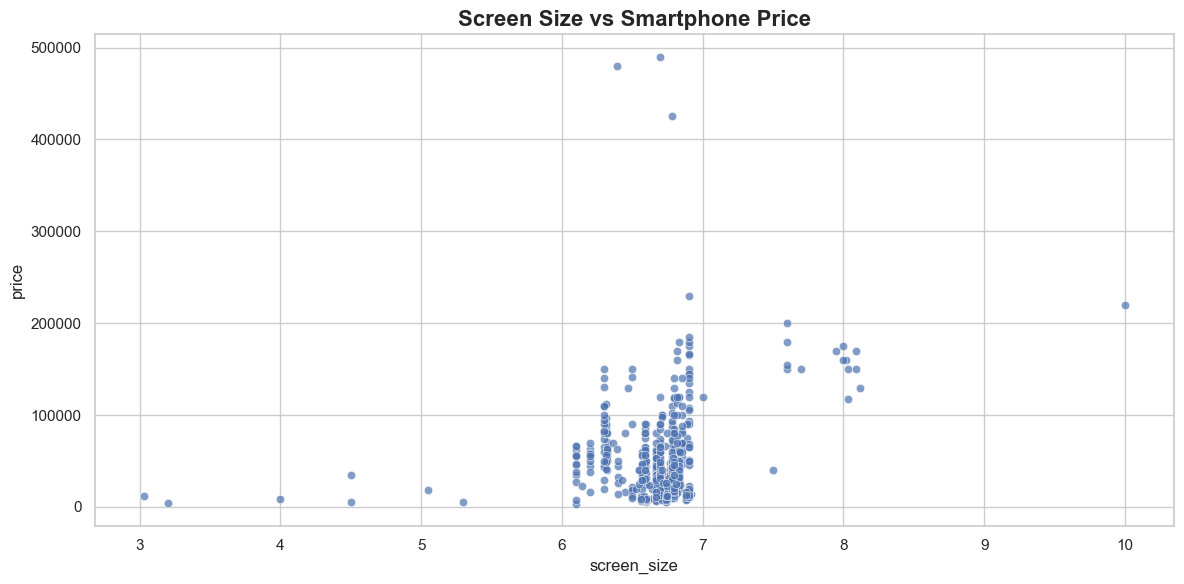

In [46]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=df, x='screen_size', y='price', alpha=0.7)

plt.title('Screen Size vs Smartphone Price',fontsize=16,fontweight='bold')
plt.tight_layout()
plt.show()

#### Business Insight
- Larger displays do not necessarily correspond to higher smartphone prices.
- Most of the smartphones screen size lies between 6.5 to 7 inches.

### 7.6 Refresh Rate vs Price

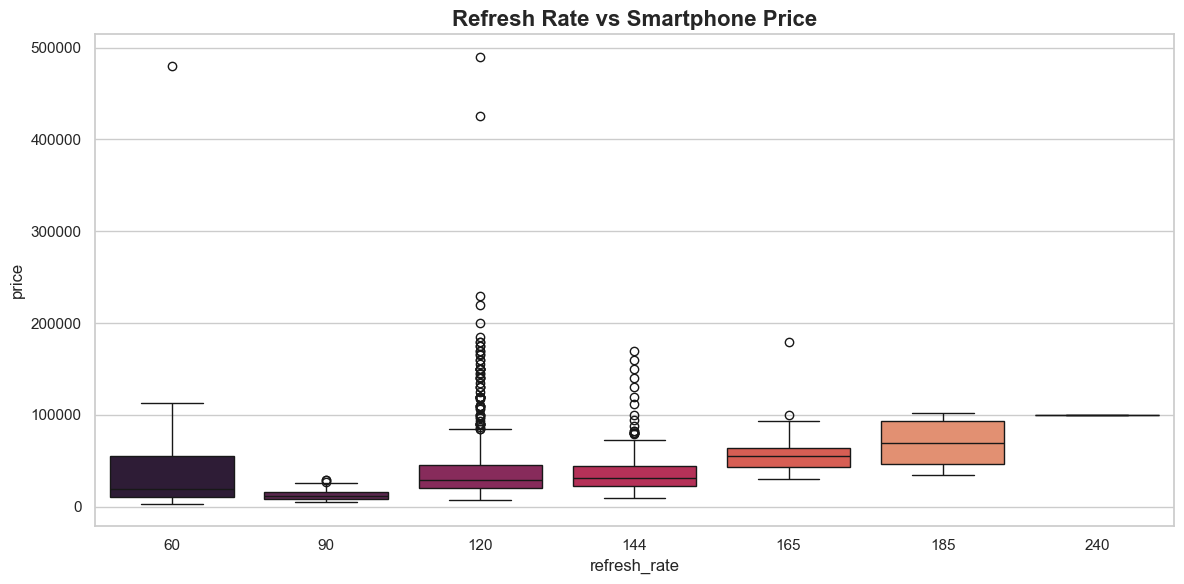

In [47]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df,x='refresh_rate', y='price', palette='rocket')
plt.title('Refresh Rate vs Smartphone Price',fontsize=16,fontweight='bold')
plt.tight_layout()
plt.show()

#### Observation
- 120 Hz devices generally common and  comes in middle price segments.
- 185 Hz and 240 Hz devices are very less and high in price as well.

#### Business Insight
- High refresh-rate displays have become an important premium feature.

### 7.7 Rear Camera vs Price

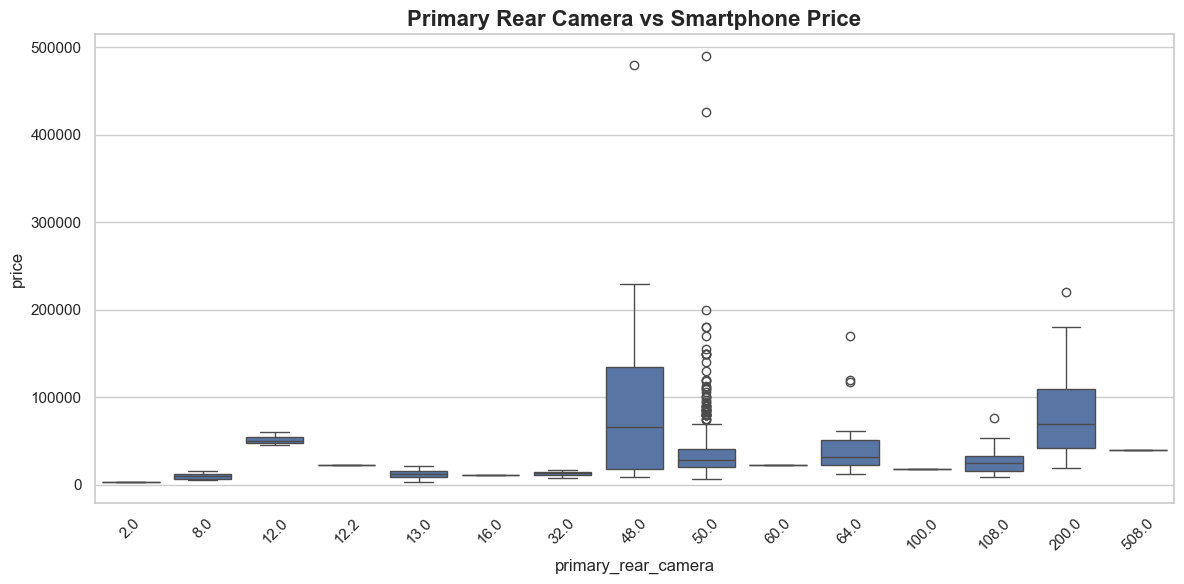

In [48]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df, x='primary_rear_camera', y='price')

plt.title('Primary Rear Camera vs Smartphone Price',fontsize=16,fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Business Insight
- Higher camera resolution tends to correspond to premium smartphones, although sensor quality also plays an important role.

### 7.8 Front Camera vs Price

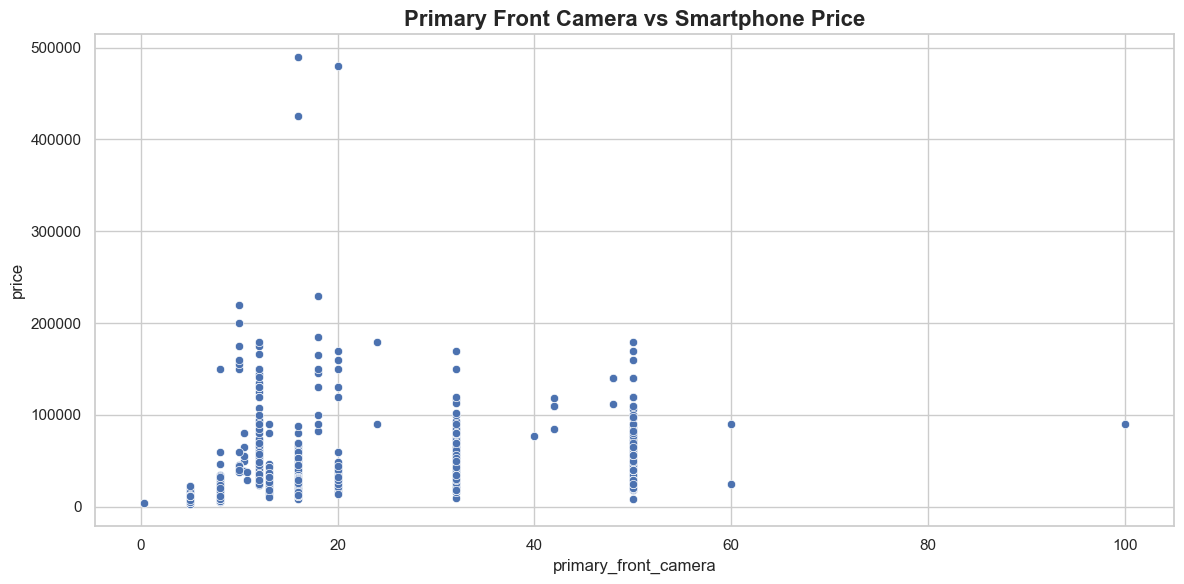

In [49]:
plt.figure(figsize=(12,6))

sns.scatterplot(data=df, x='primary_front_camera', y='price')
plt.title('Primary Front Camera vs Smartphone Price',fontsize=16,fontweight='bold')
plt.tight_layout()

plt.show()

#### Observation
- Higher front camera resolution does not consistently translate into higher smartphone prices.

### 7.9 Operating System vs Price

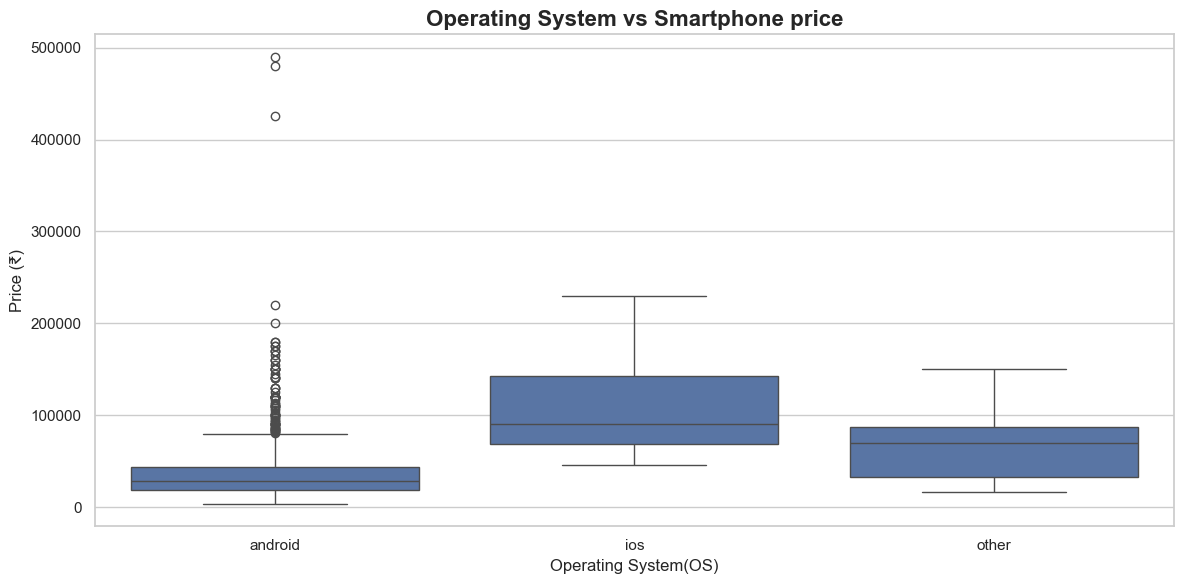

In [50]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df, x='os', y='price')

plt.title('Operating System vs Smartphone price',fontsize=16,fontweight='bold')
plt.xlabel('Operating System(OS)')
plt.ylabel('Price (₹)')
plt.tight_layout()
plt.show()

#### Business Insight
- iOS devices are concentrated in the premium segment, while Android spans all price categories.

### 7.10 5G Availability vs Price

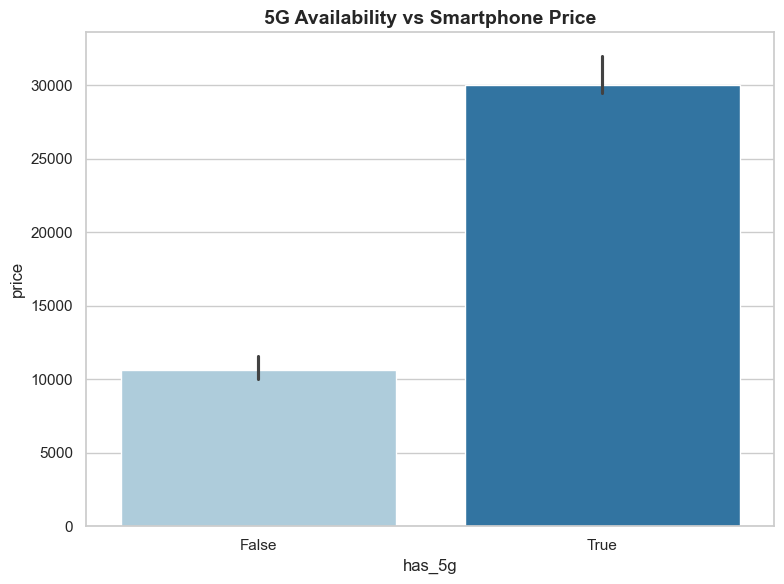

In [51]:
plt.figure(figsize=(8,6))

sns.barplot(data = df,x = 'has_5g',y = 'price',estimator = np.median,hue = 'has_5g',legend = False,palette = 'Paired')
plt.title('5G Availability vs Smartphone Price',fontsize=14,fontweight='bold')
plt.tight_layout()
plt.show()

#### Observation
- 5G smartphones generally have higher median prices.

#### Business Insight
- 5G has shifted from being an exclusive premium feature to becoming increasingly common in mid-range smartphones.

### 7.11 NFC Support vs Price

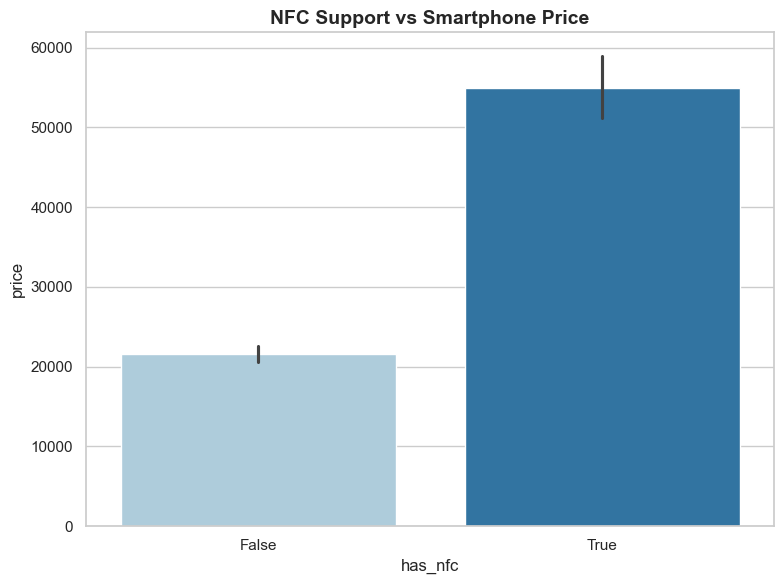

In [52]:
plt.figure(figsize=(8,6))

sns.barplot(data = df,x = 'has_nfc',y = 'price',hue = 'has_nfc',legend = False, palette = 'Paired')
plt.title('NFC Support vs Smartphone Price',fontsize=14,fontweight='bold')
plt.tight_layout()
plt.show()

#### Business Insight
- NFC support is more prevalent in premium smartphones.

### 7.12 Rating vs Price

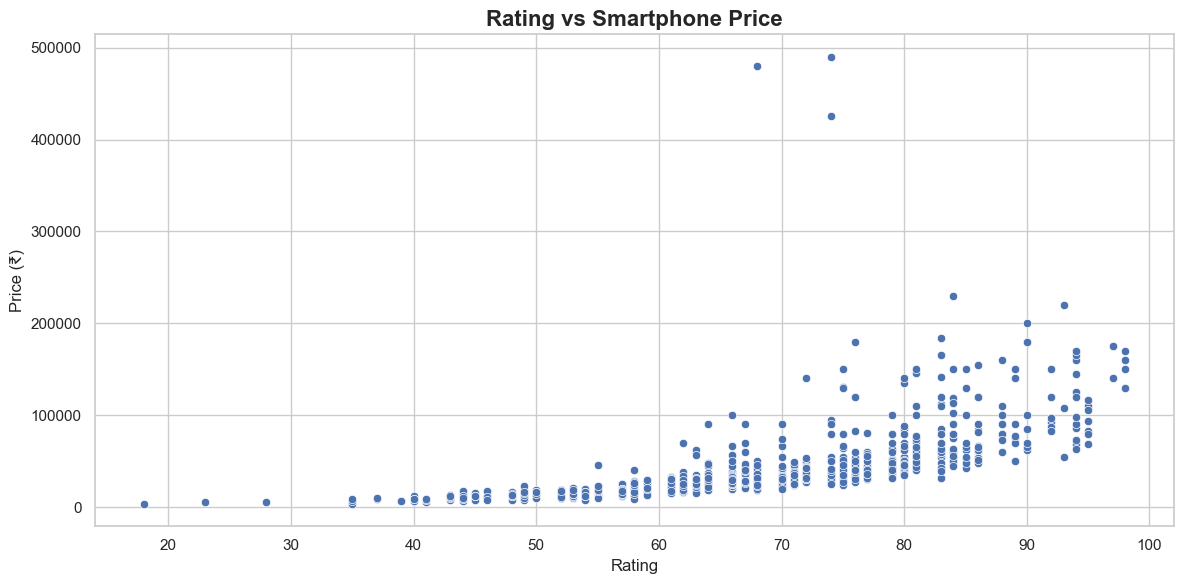

In [53]:
plt.figure(figsize=(12,6))

sns.scatterplot(data=df, x='rating', y='price')

plt.title('Rating vs Smartphone Price',fontsize=16,fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('Price (₹)')
plt.tight_layout()
plt.show()

#### Observation
- Higher-priced smartphones do not necessarily receive significantly higher ratings.

#### Business Insight
- Customer satisfaction depends on overall user experience rather than price alone.

### 7.13 Correlation Analysis
Which hardware specifications have the strongest relationship with smartphone prices?

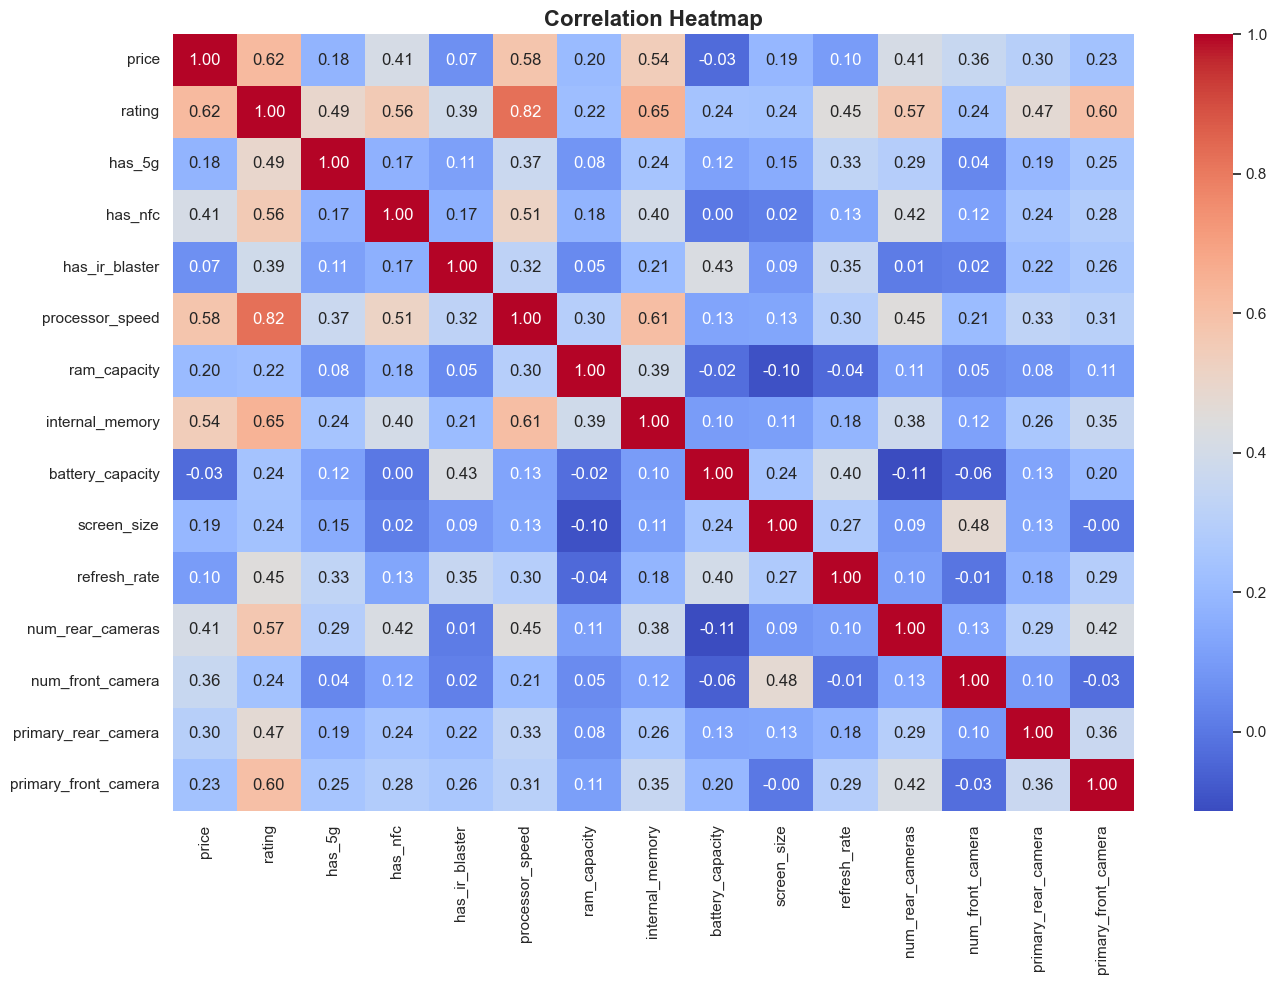

In [54]:
plt.figure(figsize=(14,10))

sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Correlation Heatmap',fontsize=16,fontweight='bold')
plt.tight_layout()
plt.show()

#### Key Findings
- RAM and internal storage show positive correlations with price.
- Processor speed has a moderate positive relationship with price.
- Battery capacity exhibits a relatively weak correlation with price.
- Ratings have little correlation with hardware specifications.

## Summary
The bivariate analysis demonstrates that smartphone pricing is influenced primarily by premium hardware specifications such as processor brand, RAM capacity, internal storage, refresh rate, and operating system. In contrast, battery capacity and camera megapixels alone have a weaker relationship with price. This suggests that manufacturers differentiate premium devices through a combination of performance, display technology, and ecosystem rather than relying on individual hardware components.

# 8. Multivariate Analysis

### 8.1 Business Question
### Which brands dominate each price segment?

In [55]:
# Price Segments
df['price_segment'] = pd.cut(
    df['price'],
    bins=[0,15000,30000,60000,df['price'].max()],
    labels=['Budget','Mid-Range','Premium','Flagship'])

<Figure size 1600x800 with 0 Axes>

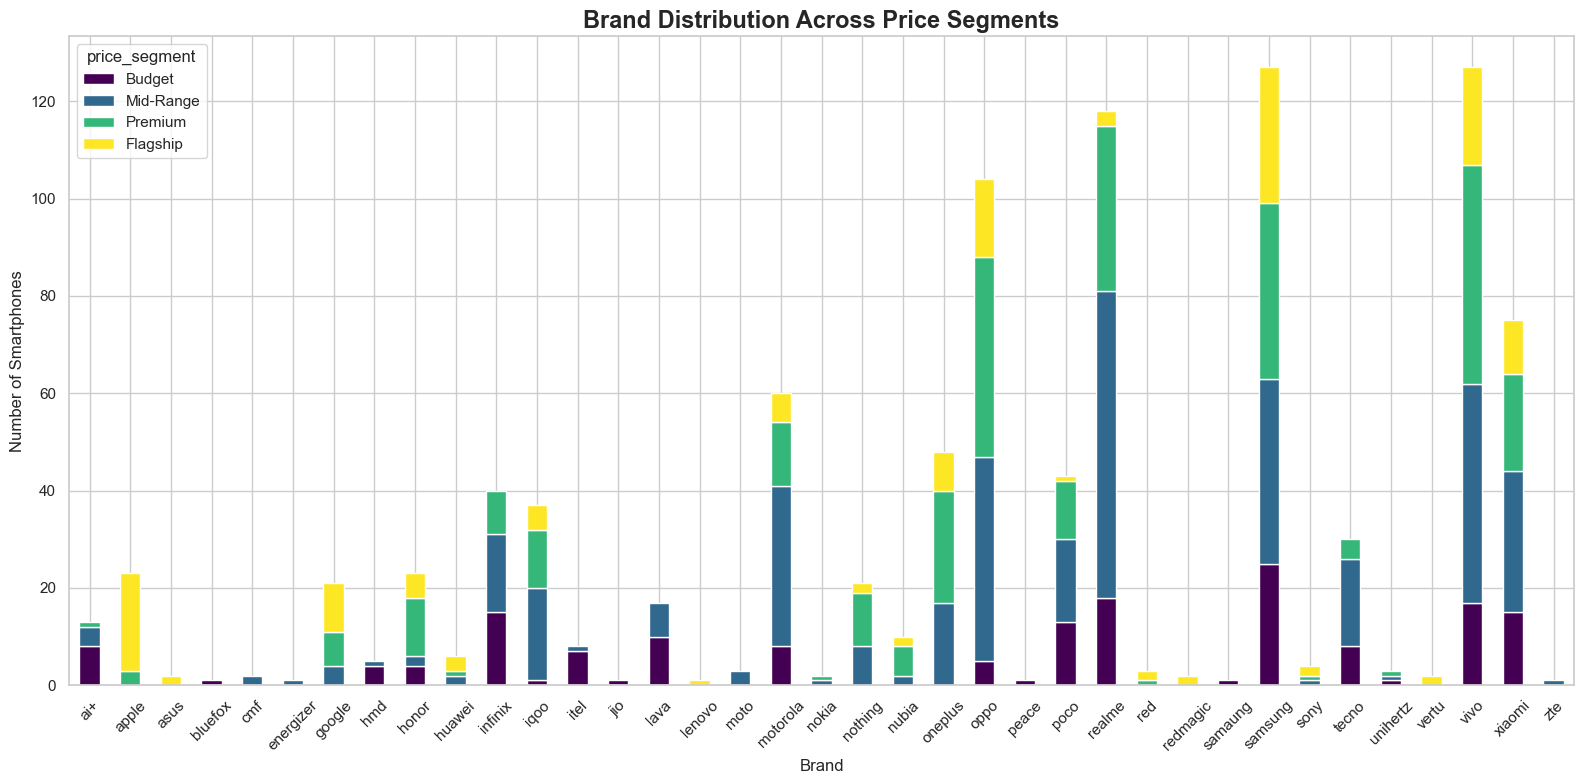

In [56]:
plt.figure(figsize=(16,8))

temp = pd.crosstab(df['brand_name'],
                   df['price_segment'])

temp.plot(kind='bar', stacked=True, figsize=(16,8), colormap='viridis')

plt.title('Brand Distribution Across Price Segments', fontsize=17, fontweight='bold')
plt.xlabel('Brand')
plt.ylabel('Number of Smartphones')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Observation
- Apple is concentrated in the Premium and Flagship segments.
- Samsung covers every price segment.
- Xiaomi and Realme dominate Budget and Mid-range categories.

#### Business Insight
- Different brands target different customer segments. Apple follows a premium strategy, while Chinese manufacturers focus on volume by covering multiple price categories.

### 8.2 Business Question
### Does RAM increase as smartphone prices increase?

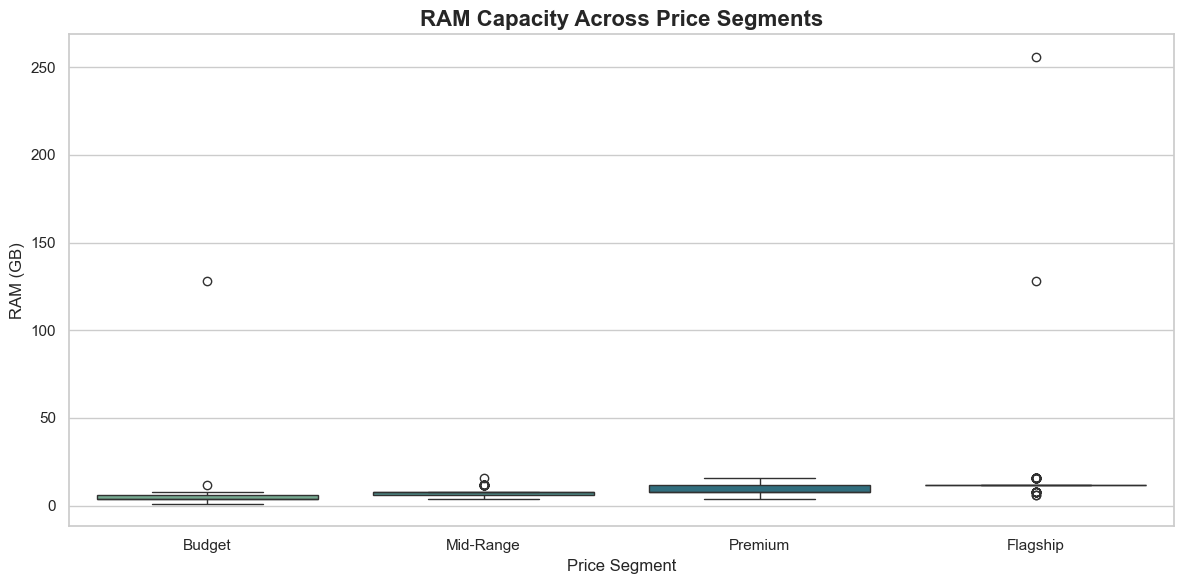

In [57]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x='price_segment',
    y='ram_capacity',
    palette='crest')

plt.title('RAM Capacity Across Price Segments',
          fontsize=16,
          fontweight='bold')

plt.xlabel('Price Segment')
plt.ylabel('RAM (GB)')
plt.tight_layout()
plt.show()

#### Business Insight
- Higher-priced smartphones generally include larger RAM capacities.

### 8.3 Business Question
### Which processor brands dominate each price segment?

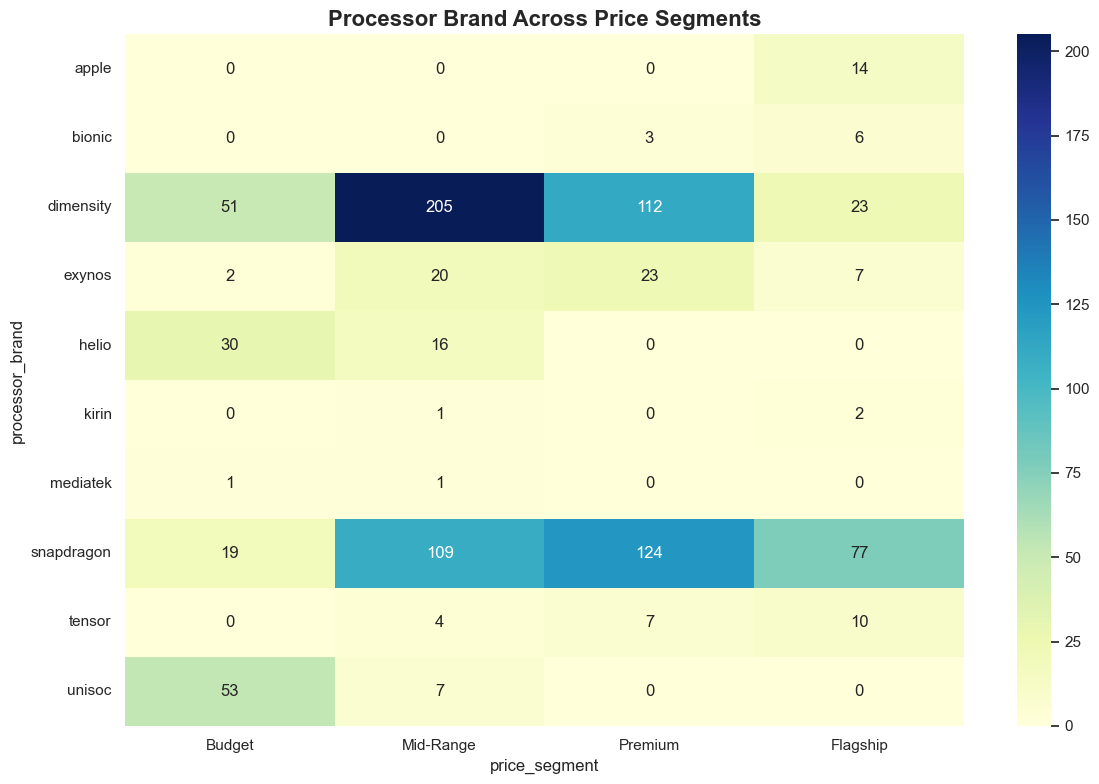

In [58]:
pivot = pd.crosstab(
    df['processor_brand'],
    df['price_segment'])

plt.figure(figsize=(12,8))
sns.heatmap(pivot, annot=True, cmap='YlGnBu', fmt='d')
plt.title('Processor Brand Across Price Segments', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

#### Observation
- snapdragon appears across every segment.
- Apple processors dominate Flagship phones.
- dimensity dominates Budget and Mid-range devices.

#### Business Insight
- Processor manufacturers target different customer segments based on performance and pricing strategies.

### 8.4 Business Question
### Do smartphones with high refresh rates also have higher prices?

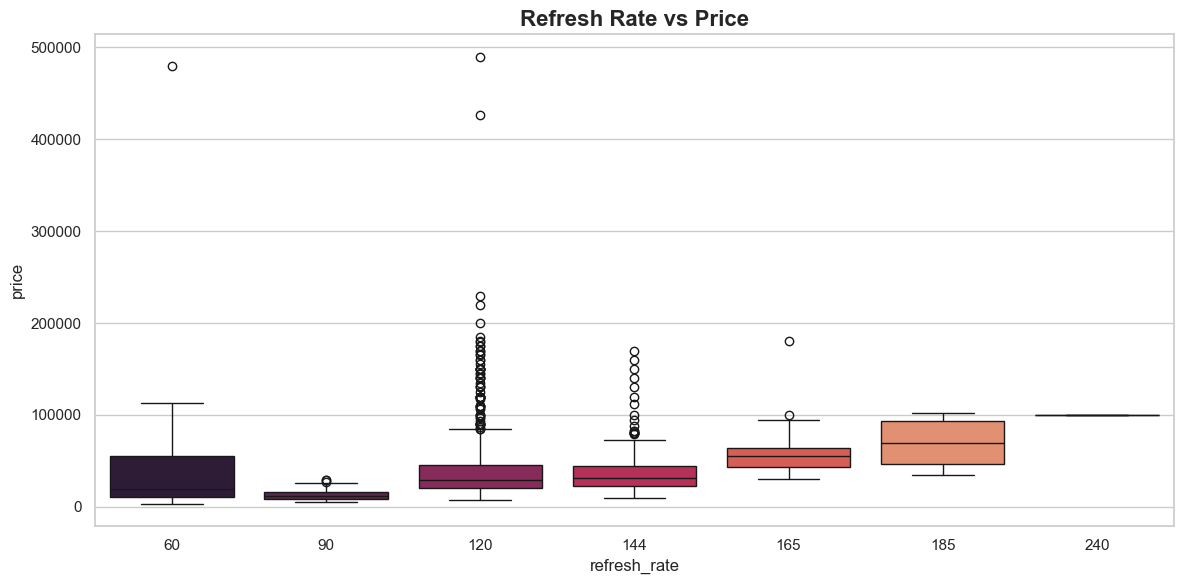

In [59]:
plt.figure(figsize=(12,6))
sns.boxplot(
    data=df,
    x='refresh_rate',
    y='price',
    palette='rocket')

plt.title('Refresh Rate vs Price', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

#### Business Insight
- Higher refresh rates are increasingly associated with premium smartphones.

# 9. Advance Correlation Analysis
#### Pairplot

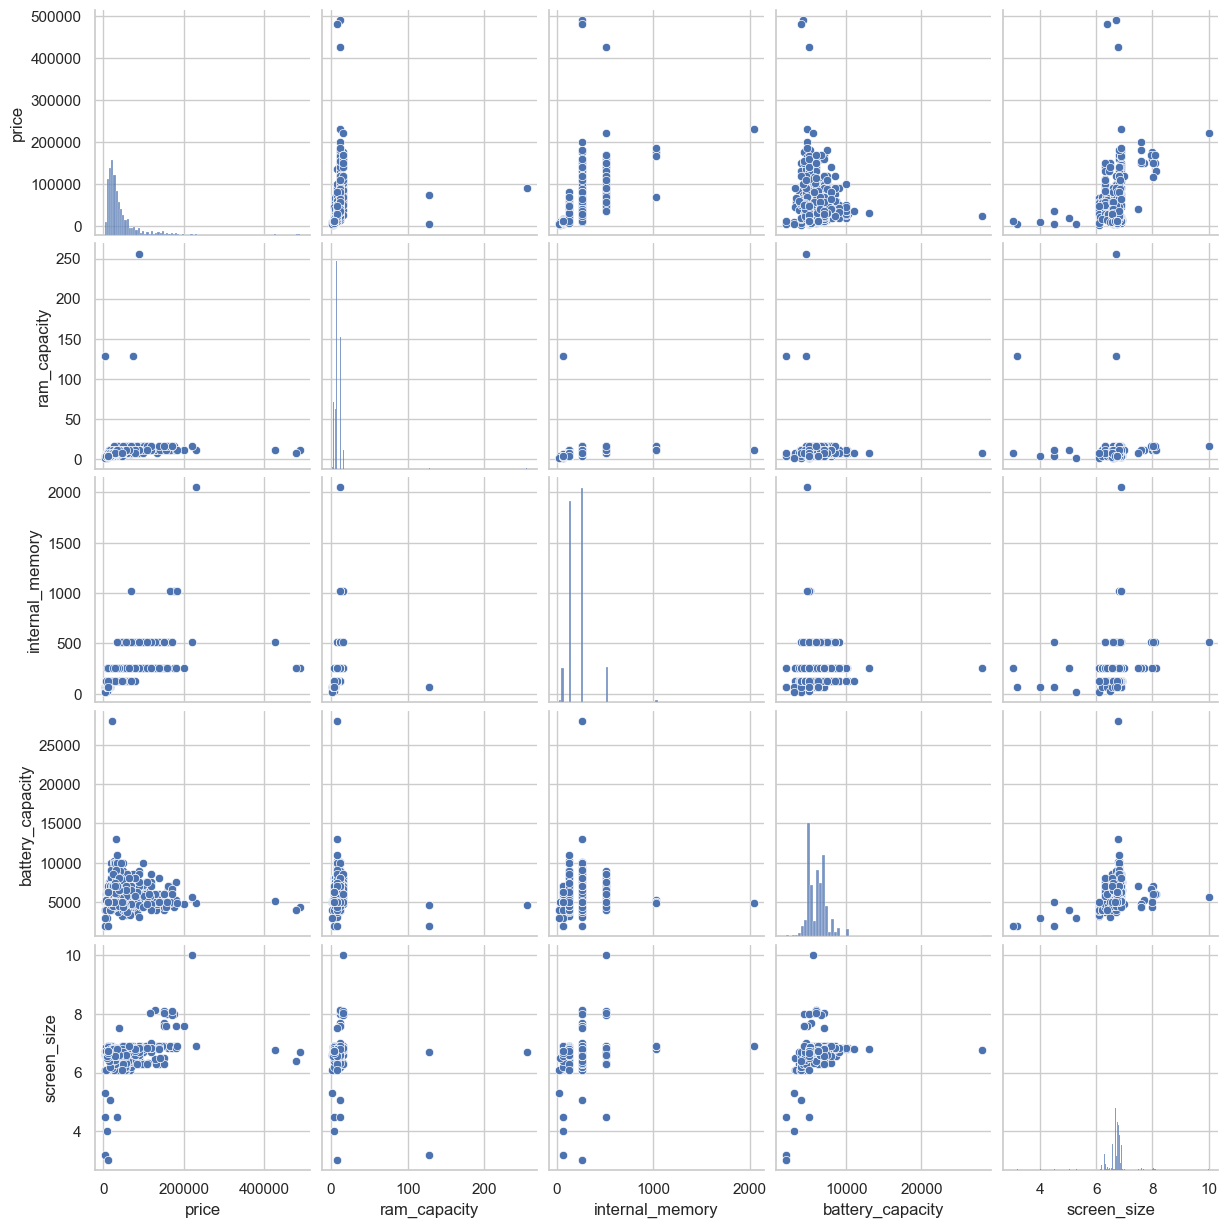

In [60]:
cols = [
    'price',
    'ram_capacity',
    'internal_memory',
    'battery_capacity',
    'screen_size']

sns.pairplot(df[cols])
plt.show()

#### Insight
- Pairwise relationships indicate that RAM and storage exhibit stronger positive associations with price than battery size.

## 10. Top 10 Most Expensive Smartphones

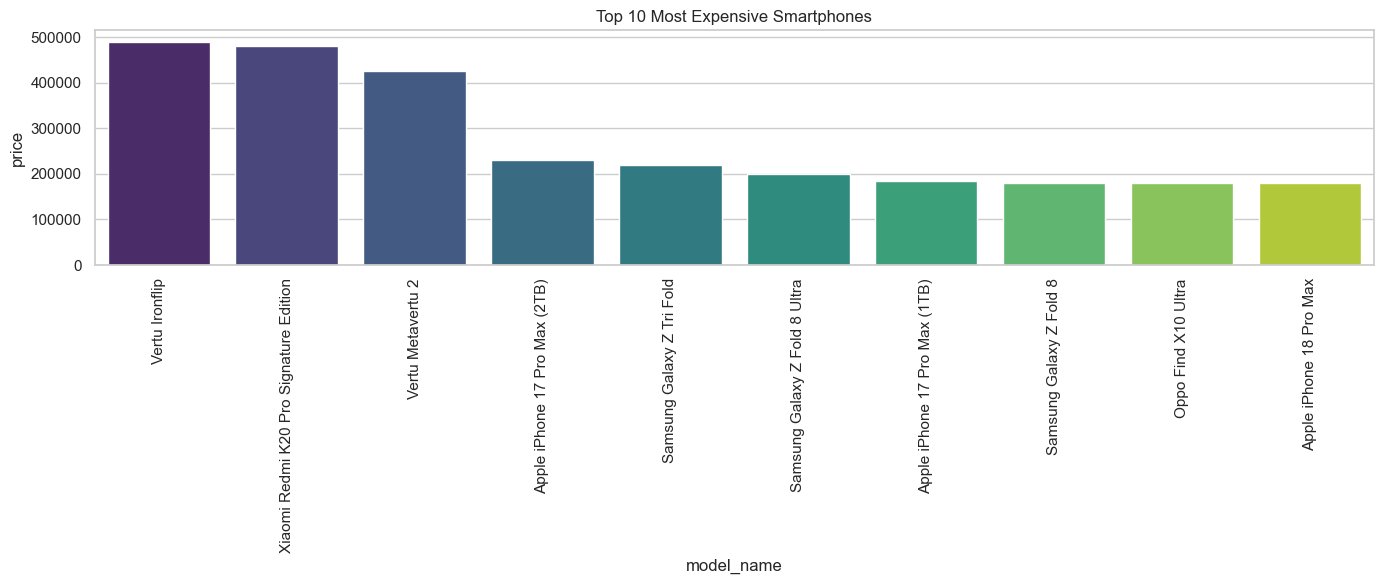

In [61]:
top10 = df.nlargest(10,'price')

plt.figure(figsize=(14,6))
sns.barplot(
    data=top10,
    x='model_name',
    y='price',
    palette='viridis')

plt.xticks(rotation=90)
plt.title('Top 10 Most Expensive Smartphones')
plt.tight_layout()
plt.show()

#### Business Insight
- Flagship smartphones from Apple and Samsung dominate the premium market.

## 11. Top 10 Cheapest Smartphones

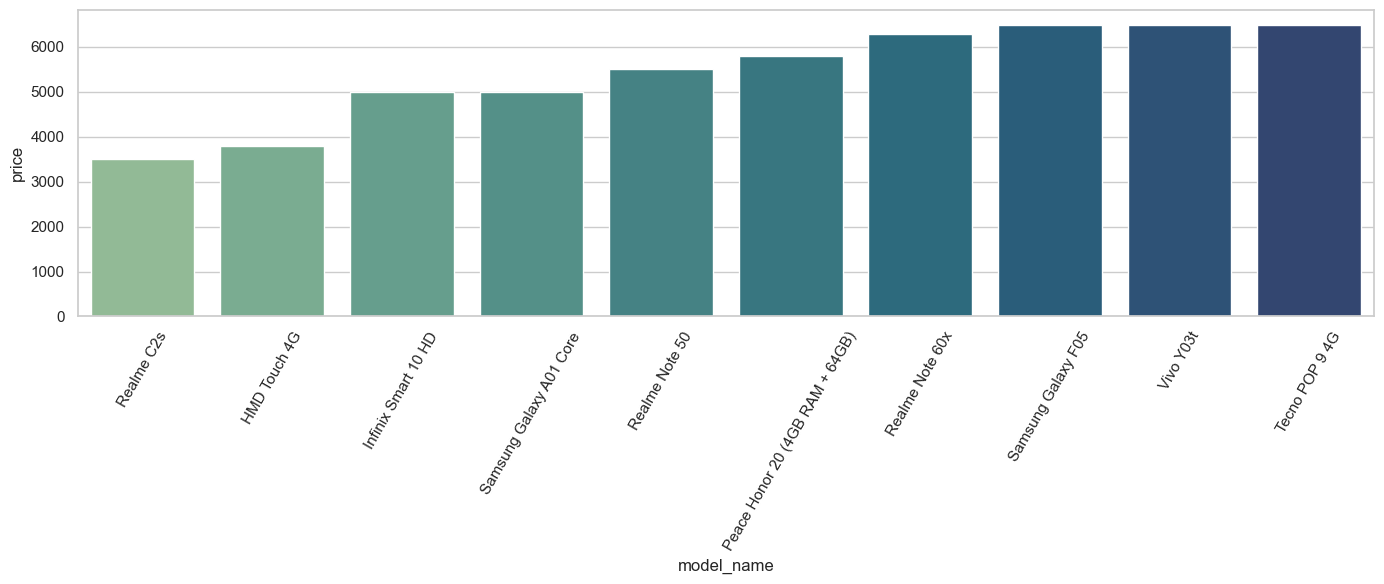

In [62]:
cheap = df.nsmallest(10,'price')

plt.figure(figsize=(14,6))
sns.barplot(
    data=cheap,
    x='model_name',
    y='price',
    palette='crest')

plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

## 12. Price Segment Distribution

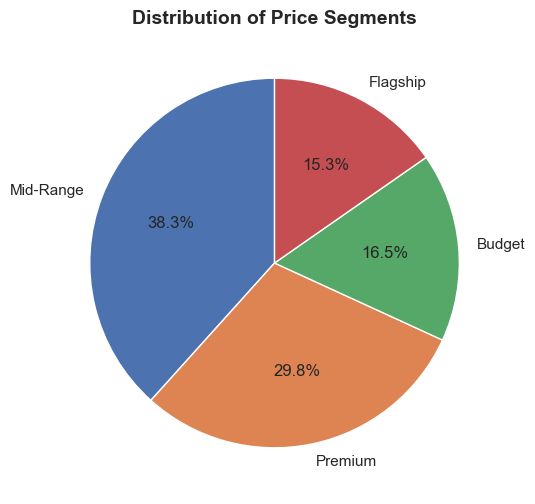

In [63]:
plt.figure(figsize=(6,6))

df['price_segment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90)

plt.title('Distribution of Price Segments',fontsize=14, fontweight='bold')
plt.ylabel('')
plt.show()

#### Insight
- Most smartphones belong to the Mid-range and Premium categories.

## 13. Executive Dashboard Metrics

In [64]:
print("Total Smartphones :",len(df))
print("Average Price :",round(df.price.mean()))
print("Median Price :",round(df.price.median()))
print("Highest Price :",df.price.max())
print("Lowest Price :",df.price.min())
print("Average Rating :",round(df.rating.mean(),2))
print("Most Common RAM :",df.ram_capacity.mode()[0])
print("Most Common Storage :",df.internal_memory.mode()[0])
print("Most Common Processor :",df.processor_brand.mode()[0])

Total Smartphones : 986
Average Price : 40028
Median Price : 28994
Highest Price : 489990
Lowest Price : 3499
Average Rating : 67.03
Most Common RAM : 8.0
Most Common Storage : 256.0
Most Common Processor : dimensity


# 14. Key Business Insights

- Android dominates the smartphone market.
- Apple follows an exclusive premium pricing strategy.
- Samsung serves customers across all price segments.
- Dimensity and Snapdragon processors dominate Android smartphones.
- 8 GB RAM has become the industry standard.
- 128 GB and 256 GB storage is the most common configuration.
- 5000 mAh batteries dominate the market.
- 120 Hz displays are becoming mainstream.
- Qual rear-camera systems are the most common configuration.
- Battery capacity alone has little influence on smartphone pricing.
- RAM, processor, storage, and refresh rate have a stronger impact on price.
- Premium smartphones differentiate themselves through an ecosystem of high-end specifications rather than a single hardware feature.

# 15. Executive Summary

- This project analyzed nearly one thousand smartphones scraped from Smartprix using Selenium and BeautifulSoup.

- The raw web data was cleaned and transformed into a structured analytical dataset using Python and Pandas. Feature engineering techniques were applied to extract meaningful variables from semi-structured specifications.

- The exploratory data analysis revealed several important trends within the smartphone market. Android devices dominate the market, while Apple maintains a premium-focused strategy. Most smartphones fall within the Premium and Mid-range price categories, with 8 GB RAM, 128 GB and 256 GB storage, 5000 mAh batteries, and 120 Hz displays emerging as the most common specifications.

- Pricing is primarily influenced by processor brand, RAM capacity, internal storage, and display technology rather than battery size alone. The analysis also highlights the increasing adoption of 5G connectivity and high refresh-rate displays across modern smartphones.

- Overall, this project demonstrates the complete data analytics lifecycle, including web scraping, data cleaning, feature engineering, exploratory data analysis, and business insight generation. The resulting dataset provides valuable insights into smartphone market trends and can serve as a foundation for predictive modeling, such as smartphone price prediction.

# 16. Final Conclusion

- This project successfully demonstrates an end-to-end data analytics workflow by collecting real-world smartphone data through web scraping, transforming it into a clean analytical dataset, and extracting meaningful business insights through exploratory data analysis.

- The findings indicate that smartphone pricing is driven by a combination of processor performance, memory configuration, storage capacity, display technology, and brand positioning. Market trends also reveal the growing standardization of features such as 5G support, 120 Hz displays, 128 GB storage, and 5000+ mAh batteries.

- This project highlights practical skills in Selenium, BeautifulSoup, Python, Pandas, NumPy, Matplotlib, and Seaborn, while showcasing the ability to derive actionable insights from real-world data. The notebook serves as a comprehensive portfolio project that reflects the complete data analytics lifecycle and demonstrates readiness for real-world data analyst responsibilities.